# Numerical extraction of quasi-normal excitation coefficients

In this notebook we develop a numerical algorithm to extract quasi-normal excitation coefficients (QNECs) directly from time-domain black-hole perturbation simulations.

The method is based on:

- numerical waveform generation,
- sliding-window QNM fitting,
- temporal alignment,
- ensemble averaging over fitting windows,
- statistical extraction of amplitudes and phases.

Unlike standard single-window ringdown fits, the algorithm constructs a statistical ensemble of QNM coefficients across many fitting windows, allowing robust identification of stable excitation structures in amplitude-phase space.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pickle

from joblib import Parallel, delayed

import qnm
import rw_solver as rw

In [59]:
import numpy as np
import matplotlib.pyplot as plt
from joblib import Parallel, delayed
import qnm
import rw_solver as rw
# ============================================================
# CELL 0 — GLOBAL SETUP (l = 2)
# ============================================================

# ---------- Mode identifier ----------
ell = 2

# ---------- BH and perturbation physical parameters ----------
Mbh          = 1.0
l_mode_l2    = ell
m_mode_l2    = 0

A_init_l2    = 1.0      # ID amplitude
r0_l2        = 100.0    # ID position
r_obs_target_l2 = 100.0 # observer

# ---------- Simulation grid (tortoise) ----------
x_min, x_max = -200.0, 1500.0
Ngrid        = 8000
TF           = 500.0
CFL          = 0.1

# ---------- Peak search in the waveform ----------
t_search_min = 195.0
t_search_max = 205.0

# ---------- QNM modes to fit (n=0 to start) ----------
n_list = [0]
modes_l2 = [(l_mode_l2, m_mode_l2, n, 1) for n in n_list]

def get_qnm_omegas(ell, m_q, n_list, chif=0.0, Mf=1.0, s_spin=-2):
    omegas = []
    for n in n_list:
        mode = qnm.modes_cache(s=s_spin, l=ell, m=m_q, n=n)
        w, _, _ = mode(a=chif)
        omegas.append(w / Mf)
    return np.array(omegas, dtype=complex)

omegas_l2 = get_qnm_omegas(l_mode_l2, m_mode_l2, n_list)
N_modes_l2 = len(omegas_l2)

print(f"[l={ell}] Loaded modes: {modes_l2}")
print(f"[l={ell}] QNM frequencies (M=1): {omegas_l2}")

# ---------- Sliding fit parameters ----------
T_window = 10.0   # fit window length
dt_scan  = 0.07   # sliding step in t0
min_pts  = 20     # minimum number of points per window

# ============================================================
# NEW EXPERIMENT: fixed sigma, sweep over nu
# ============================================================

sigma_l2 = 5.0

nu_min, nu_max, dnu = 0.0, 1.0, 0.001
nu_grid_l2 = np.arange(nu_min, nu_max + dnu, dnu)
n_nu_l2 = len(nu_grid_l2)

print(f"[l={ell}] Sweep over nu: {n_nu_l2} values in [{nu_min}, {nu_max}] with step {dnu}")
print(f"[l={ell}] Fixed sigma = {sigma_l2}")

# ---------- Parallelization ----------
N_JOBS = 7

[l=2] Loaded modes: [(2, 0, 0, 1)]
[l=2] QNM frequencies (M=1): [0.37367168-0.08896232j]
[l=2] Sweep over nu: 1001 values in [0.0, 1.0] with step 0.001
[l=2] Fixed sigma = 5.0


### simulacion

[l=2] Lanzando 1001 simulaciones (sigma=5.0)...


/Users/uib/Desktop/examples/rw_solver.py:17: RuntimeWarning: overflow encountered in exp
  z = np.exp(s/(2.0*M) - 1.0)
/Users/uib/Desktop/examples/rw_solver.py:17: RuntimeWarning: overflow encountered in exp
  z = np.exp(s/(2.0*M) - 1.0)
/Users/uib/Desktop/examples/rw_solver.py:17: RuntimeWarning: overflow encountered in exp
  z = np.exp(s/(2.0*M) - 1.0)
/Users/uib/Desktop/examples/rw_solver.py:17: RuntimeWarning: overflow encountered in exp
  z = np.exp(s/(2.0*M) - 1.0)
/Users/uib/Desktop/examples/rw_solver.py:17: RuntimeWarning: overflow encountered in exp
  z = np.exp(s/(2.0*M) - 1.0)
/opt/homebrew/Caskroom/miniforge/base/lib/python3.9/site-packages/joblib/externals/loky/process_executor.py:702: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
/Users/uib/Desktop/examples/rw_solver.py:17: RuntimeWarning: overflow encountered in exp
  z = np.exp(s/(2.0*M) - 1.0)
/Users/uib/D

[l=2] Simulaciones completadas: 1001 waveforms.


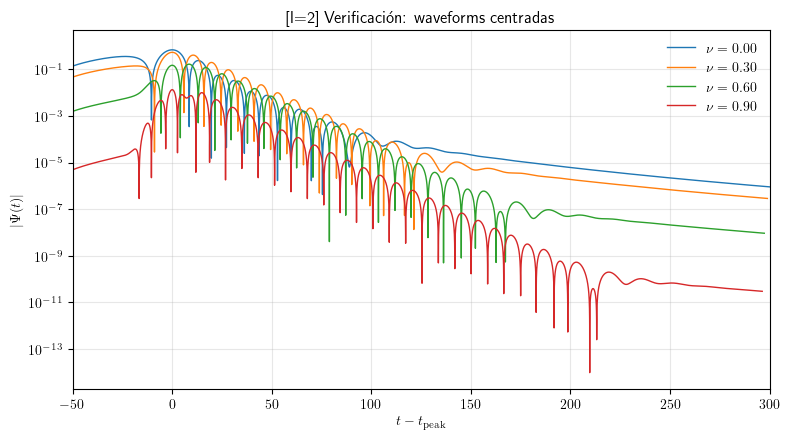

In [ ]:
# ============================================================
# CELL 1 — NUMERICAL SIMULATION (l = 2, sweep over nu)
# ============================================================

def run_one_simulation_l2(nu):
    """
    Simulation for a given value of nu (fixed sigma).

    Returns
    -------
    nu : float
    t_centered : ndarray
    Psi_t : ndarray
    t_peak : float
    """

    # 1) ID (fixed sigma)
    Psi0 = rw.gaussiana(
        A_init_l2, x_min, x_max, Ngrid,
        nu, r0_l2, sigma_l2
    )

    # 2) Evolution
    U, T, s_grid = rw.simula_full(
        N=Ngrid, x_min=x_min, x_max=x_max,
        Psi_initial=Psi0, TF=TF, CFL=CFL,
        l=l_mode_l2, M=Mbh
    )

    # 3) Waveform at r_obs
    wf = rw.extract_observer_4th(U, s_grid, r_obs_target_l2)
    del U  # free memory

    # 4) Peak inside the physical window
    abs_wf = np.abs(wf)
    mask = (T >= t_search_min) & (T <= t_search_max)

    if not np.any(mask):
        raise RuntimeError(
            f"No points in [{t_search_min}, {t_search_max}] for nu={nu}"
        )

    i_peak = np.where(mask)[0][np.argmax(abs_wf[mask])]
    t_peak = T[i_peak]

    # 5) Centering
    t_centered = T - t_peak
    Psi_t = np.real(wf)

    return nu, t_centered, Psi_t, t_peak


# ------------------------------------------------------------
# Parallel execution over nu
# ------------------------------------------------------------
print(f"[l=2] Launching {n_nu_l2} simulations (sigma={sigma_l2})...")

waveforms_raw_l2 = Parallel(n_jobs=N_JOBS)(
    delayed(run_one_simulation_l2)(nu)
    for nu in nu_grid_l2
)

# Dictionary indexed by nu
waveforms_l2 = {
    nu: {'t_centered': t_c, 'Psi_t': psi, 't_peak': tp}
    for (nu, t_c, psi, tp) in waveforms_raw_l2
}

print(f"[l=2] Completed simulations: {len(waveforms_l2)} waveforms.")


# ------------------------------------------------------------
# Quick verification
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 4.5))

for nu_check in [0.0, 0.3, 0.6, 0.9]:
    idx = np.argmin(np.abs(nu_grid_l2 - nu_check))
    nu_real = nu_grid_l2[idx]

    d = waveforms_l2[nu_real]
    ax.plot(d['t_centered'], np.abs(d['Psi_t']),
            lw=1.0, label=fr'$\nu = {nu_real:.2f}$')

ax.set_yscale('log')
ax.set_xlabel(r'$t - t_{\rm peak}$')
ax.set_ylabel(r'$|\Psi(t)|$')
ax.set_xlim(-50, 300)
ax.grid(alpha=0.3, which='both')
ax.legend(frameon=False)
ax.set_title(r'[l=2] Verification: centered waveforms')
plt.tight_layout()
plt.show()

In [ ]:
save_data_l2 = {
    'waveforms_l2': waveforms_l2,
    'nu_grid_l2': nu_grid_l2,
    'sigma_l2': sigma_l2,
    'params': {
        'Ngrid': Ngrid,
        'TF': TF,
        'CFL': CFL,
        'l_mode_l2': l_mode_l2,
        'Mbh': Mbh,
        'r_obs_target_l2': r_obs_target_l2,
        'r0_l2': r0_l2,
        't_search_min': t_search_min,
        't_search_max': t_search_max
    }
}

with open("waveforms_l2_nu_scan.pkl", "wb") as f:
    pickle.dump(save_data_l2, f)

print("Results saved in waveforms_l2_nu_scan.pkl")

Resultados guardados en waveforms_l2_nu_scan.pkl


### carga datos

In [ ]:
import pickle
with open("waveforms_l2_nu_scan.pkl", "rb") as f:
    data_l2 = pickle.load(f)

waveforms_l2 = data_l2['waveforms_l2']
nu_grid_l2 = data_l2['nu_grid_l2']
sigma_l2 = data_l2['sigma_l2']

print(f"Loaded waveforms: {len(waveforms_l2)}")
print(f"Fixed sigma: {sigma_l2}")
print(f"Number of nu values: {len(nu_grid_l2)}")

Waveforms cargadas: 1001
Sigma fijo: 5.0
Número de valores de nu: 1001


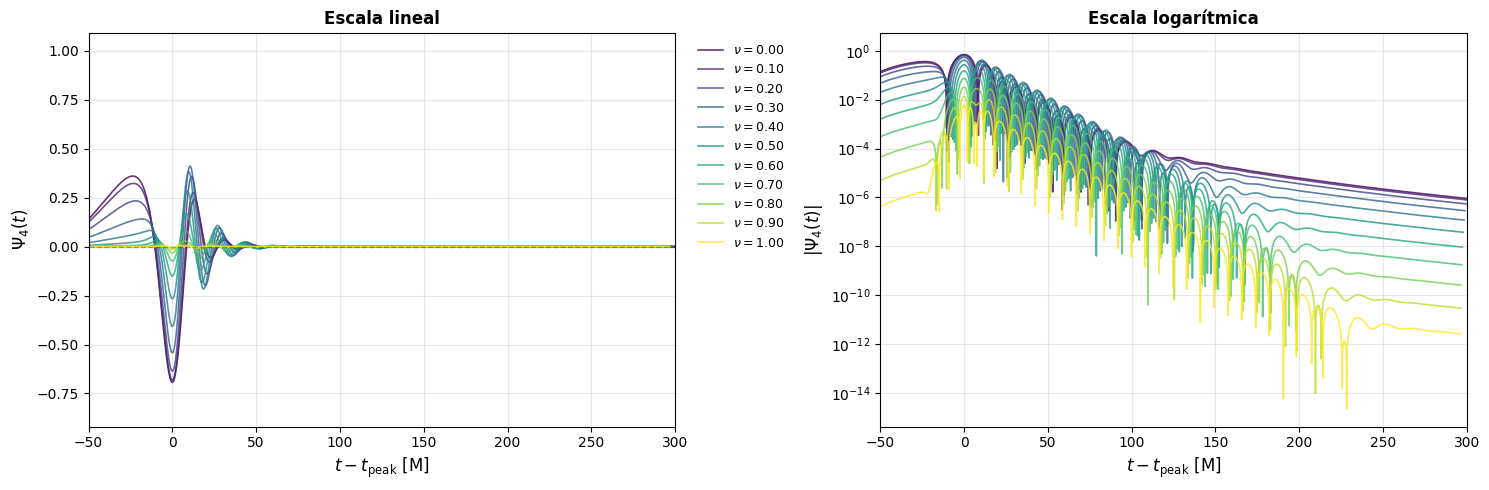

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Select 10 waveforms every 0.1 in nu
nu_subset = np.arange(0.0, 1.0 + 0.05, 0.1)  # [0.0, 0.1, 0.2, ..., 0.9]
colors = plt.cm.viridis(np.linspace(0, 1, len(nu_subset)))

for nu_val, color in zip(nu_subset, colors):
    # Find the closest index in nu_grid_l2
    idx = np.argmin(np.abs(nu_grid_l2 - nu_val))
    nu_real = nu_grid_l2[idx]
    
    d = waveforms_l2[nu_real]
    t_c = d['t_centered']
    psi = d['Psi_t']
    
    # Linear scale
    ax1.plot(t_c, psi, lw=1.2, color=color, alpha=0.8, label=fr'$\nu = {nu_real:.2f}$')
    
    # Logarithmic scale
    ax2.semilogy(t_c, np.abs(psi), lw=1.2, color=color, alpha=0.8, label=fr'$\nu = {nu_real:.2f}$')

# Customize linear plot
ax1.axhline(0, color='black', linestyle='--', alpha=0.3, lw=1)
ax1.set_xlabel(r'$t - t_{\rm peak}$ [M]', fontsize=12)
ax1.set_ylabel(r'$\Psi_4(t)$', fontsize=12)
ax1.set_title('Linear scale', fontsize=12, fontweight='bold')
ax1.grid(alpha=0.3)
ax1.set_xlim(-50, 300)
ax1.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9, frameon=False, ncol=1)

# Customize logarithmic plot
ax2.set_xlabel(r'$t - t_{\rm peak}$ [M]', fontsize=12)
ax2.set_ylabel(r'$|\Psi_4(t)|$', fontsize=12)
ax2.set_title('Logarithmic scale', fontsize=12, fontweight='bold')
ax2.grid(alpha=0.3, which='both')
ax2.set_xlim(-50, 300)

plt.tight_layout()
plt.show()

In [ ]:
# Display t_peak for all nu values
print("\nt_peak for each nu value:")
print("=" * 40)
for nu_val in nu_grid_l2:
    t_p = waveforms_l2[nu_val]['t_peak']
    print(f"nu = {nu_val:.3f}  →  t_peak = {t_p:.3f} [M]")


t_peak para cada valor de nu:
nu = 0.000  →  t_peak = 199.945 [M]
nu = 0.001  →  t_peak = 199.945 [M]
nu = 0.002  →  t_peak = 199.945 [M]
nu = 0.003  →  t_peak = 199.945 [M]
nu = 0.004  →  t_peak = 199.945 [M]
nu = 0.005  →  t_peak = 199.945 [M]
nu = 0.006  →  t_peak = 199.945 [M]
nu = 0.007  →  t_peak = 199.945 [M]
nu = 0.008  →  t_peak = 199.945 [M]
nu = 0.009  →  t_peak = 199.945 [M]
nu = 0.010  →  t_peak = 199.945 [M]
nu = 0.011  →  t_peak = 199.945 [M]
nu = 0.012  →  t_peak = 199.945 [M]
nu = 0.013  →  t_peak = 199.945 [M]
nu = 0.014  →  t_peak = 199.945 [M]
nu = 0.015  →  t_peak = 199.945 [M]
nu = 0.016  →  t_peak = 199.945 [M]
nu = 0.017  →  t_peak = 199.945 [M]
nu = 0.018  →  t_peak = 199.945 [M]
nu = 0.019  →  t_peak = 199.945 [M]
nu = 0.020  →  t_peak = 199.945 [M]
nu = 0.021  →  t_peak = 199.945 [M]
nu = 0.022  →  t_peak = 199.945 [M]
nu = 0.023  →  t_peak = 199.966 [M]
nu = 0.024  →  t_peak = 199.966 [M]
nu = 0.025  →  t_peak = 199.966 [M]
nu = 0.026  →  t_peak = 199.966 [

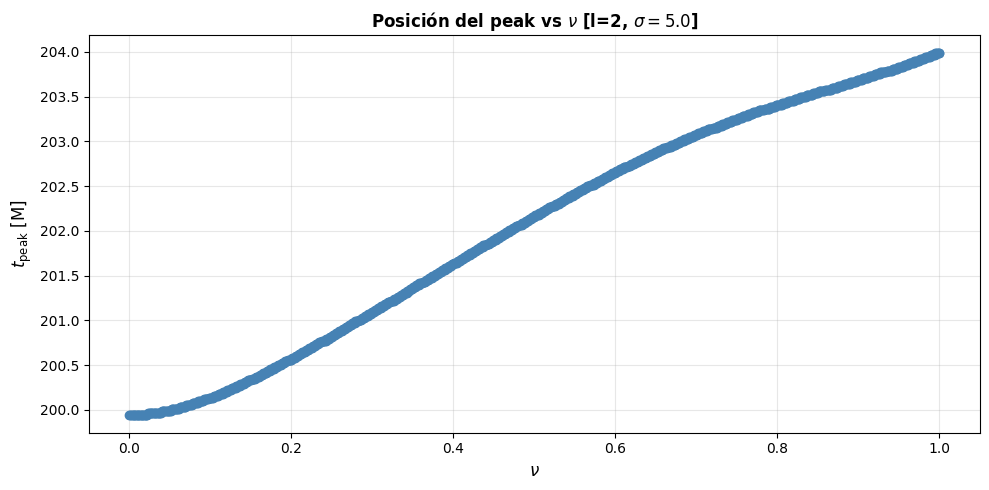


t_peak min: 199.945 [M]
t_peak max: 203.983 [M]
Rango: 4.038 [M]


In [ ]:
# Extract t_peak for all nu values
t_peaks = [waveforms_l2[nu_val]['t_peak'] for nu_val in nu_grid_l2]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(nu_grid_l2, t_peaks, 'o-', lw=2, markersize=6, color='steelblue')
ax.set_xlabel(r'$\nu$', fontsize=12)
ax.set_ylabel(r'$t_{\rm peak}$ [M]', fontsize=12)
ax.set_title(fr'Peak position vs $\nu$ [l=2, $\sigma = {sigma_l2:.1f}$]', fontsize=12, fontweight='bold')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nt_peak min: {min(t_peaks):.3f} [M]")
print(f"t_peak max: {max(t_peaks):.3f} [M]")
print(f"Range: {max(t_peaks) - min(t_peaks):.3f} [M]")

t_peak de referencia: 202.034 [M]

Desplazamientos:
nu = 0.00  →  t_peak = 199.945  →  Δt = -2.089
nu = 0.10  →  t_peak = 200.136  →  Δt = -1.897
nu = 0.20  →  t_peak = 200.561  →  Δt = -1.472
nu = 0.30  →  t_peak = 201.093  →  Δt = -0.941
nu = 0.40  →  t_peak = 201.624  →  Δt = -0.410
nu = 0.50  →  t_peak = 202.155  →  Δt = +0.122
nu = 0.60  →  t_peak = 202.644  →  Δt = +0.610
nu = 0.70  →  t_peak = 203.069  →  Δt = +1.035
nu = 0.80  →  t_peak = 203.409  →  Δt = +1.375
nu = 0.90  →  t_peak = 203.685  →  Δt = +1.652
nu = 1.00  →  t_peak = 203.983  →  Δt = +1.949


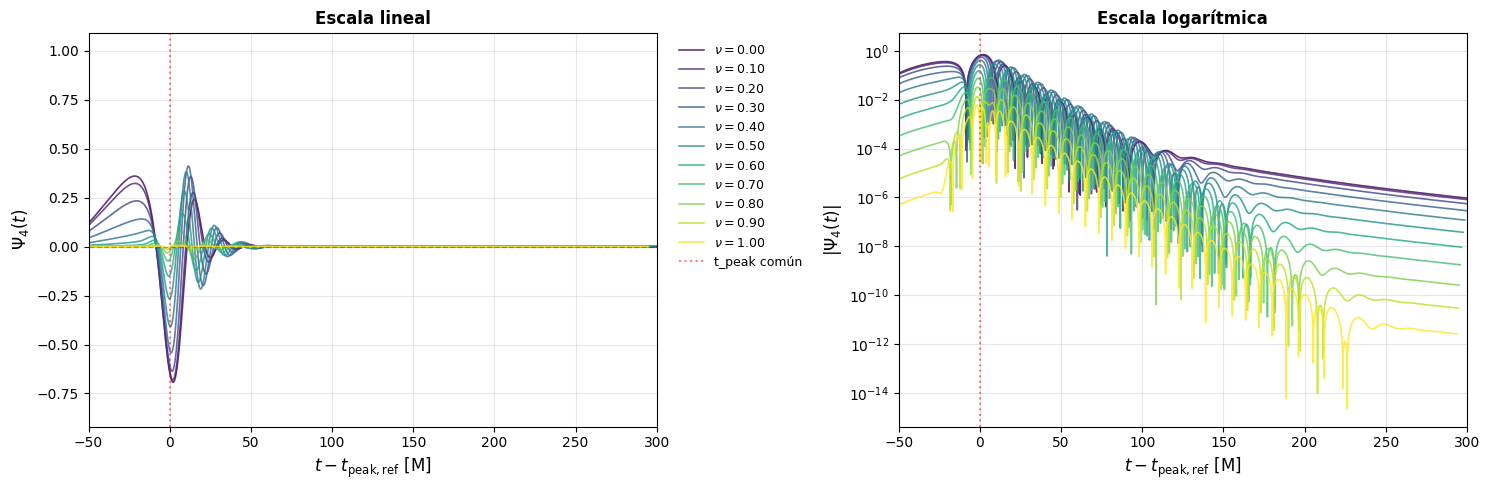

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Select 10 waveforms every 0.1 in nu
nu_subset = np.arange(0.0, 1.0 + 0.05, 0.1)
colors = plt.cm.viridis(np.linspace(0, 1, len(nu_subset)))

# Compute reference t_peak (average over all values)
t_peaks_all = [waveforms_l2[nu_val]['t_peak'] for nu_val in nu_grid_l2]
t_peak_ref = np.mean(t_peaks_all)

print(f"Reference t_peak: {t_peak_ref:.3f} [M]")
print("\nShifts:")
print("=" * 45)

for nu_val, color in zip(nu_subset, colors):
    # Find the closest index in nu_grid_l2
    idx = np.argmin(np.abs(nu_grid_l2 - nu_val))
    nu_real = nu_grid_l2[idx]
    
    d = waveforms_l2[nu_real]
    t_c = d['t_centered']
    psi = d['Psi_t']
    t_peak_actual = d['t_peak']
    
    # Required shift to align with t_peak_ref
    delta_t = t_peak_actual - t_peak_ref
    t_aligned = t_c - delta_t  # Subtract because t_centered is already centered on its own peak
    
    print(f"nu = {nu_real:.2f}  →  t_peak = {t_peak_actual:.3f}  →  Δt = {delta_t:+.3f}")
    
    # Linear scale
    ax1.plot(t_aligned, psi, lw=1.2, color=color, alpha=0.8, label=fr'$\nu = {nu_real:.2f}$')
    
    # Logarithmic scale
    ax2.semilogy(t_aligned, np.abs(psi), lw=1.2, color=color, alpha=0.8, label=fr'$\nu = {nu_real:.2f}$')

# Customize linear plot
ax1.axhline(0, color='black', linestyle='--', alpha=0.3, lw=1)
ax1.axvline(0, color='red', linestyle=':', alpha=0.5, lw=1.5, label='common t_peak')
ax1.set_xlabel(r'$t - t_{\rm peak, ref}$ [M]', fontsize=12)
ax1.set_ylabel(r'$\Psi_4(t)$', fontsize=12)
ax1.set_title('Linear scale', fontsize=12, fontweight='bold')
ax1.grid(alpha=0.3)
ax1.set_xlim(-50, 300)
ax1.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9, frameon=False, ncol=1)

# Customize logarithmic plot
ax2.axvline(0, color='red', linestyle=':', alpha=0.5, lw=1.5, label='common t_peak')
ax2.set_xlabel(r'$t - t_{\rm peak, ref}$ [M]', fontsize=12)
ax2.set_ylabel(r'$|\Psi_4(t)|$', fontsize=12)
ax2.set_title('Logarithmic scale', fontsize=12, fontweight='bold')
ax2.grid(alpha=0.3, which='both')
ax2.set_xlim(-50, 300)

plt.tight_layout()
plt.show()

### primera extraccion de Cn

[l=2] Lanzando fits para 1001 waveforms...
[l=2] Fits completados: 1001 curvas C_n(t0).


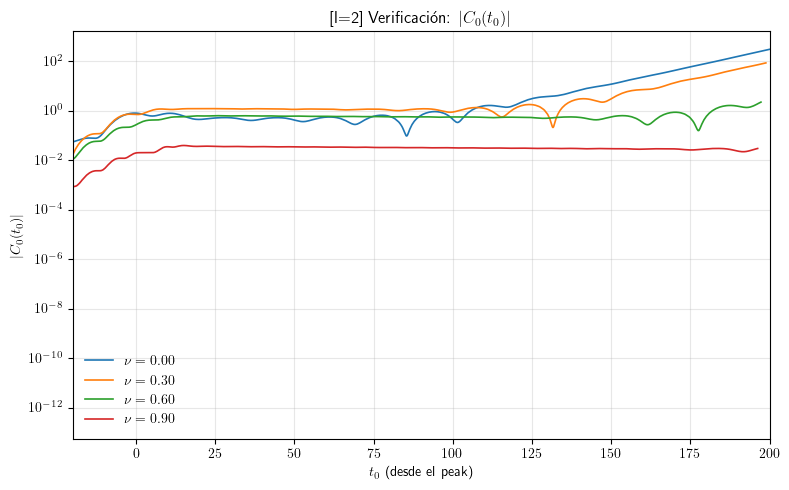

In [ ]:
# ============================================================
# CELL 2 — SLIDING QNM FIT (l = 2)
# ============================================================
# ---------- Sliding fit parameters ----------
T_window = 100.0   # fit window length
dt_scan  = 0.07    # sliding step in t0
min_pts  = 20      # minimum number of points per window

def sequential_window_fit(t, data, omegas, T_window, dt_scan, min_pts=20):
    t = np.asarray(t)
    data = np.asarray(data, dtype=float)
    omegas = np.asarray(omegas, dtype=complex)

    t0_values = np.arange(t.min(), t.max() - T_window, dt_scan)

    t0_list = []
    C_lists = [[] for _ in omegas]

    for t0 in t0_values:
        mask = (t >= t0) & (t <= t0 + T_window)
        Tw = t[mask]
        Yw = data[mask]

        if len(Tw) < min_pts:
            continue

        Y_res = Yw.copy()

        for i, omega in enumerate(omegas):
            X = np.exp(-1j * omega * Tw)

            # Real-imaginary fit
            M = np.column_stack([np.real(X), -np.imag(X)])
            theta, *_ = np.linalg.lstsq(M, Y_res, rcond=None)

            Ci = theta[0] + 1j * theta[1]
            C_lists[i].append(Ci)

            # Subtract contribution
            Y_res = Y_res - np.real(Ci * X)

        t0_list.append(t0)

    return np.asarray(t0_list), np.array(C_lists).T


# ------------------------------------------------------------
# Apply to all waveforms (indexed by nu)
# ------------------------------------------------------------
def fit_one_waveform_l2(nu, d):
    t0_arr, C_matrix = sequential_window_fit(
        d['t_centered'], d['Psi_t'],
        omegas_l2,
        T_window=T_window,
        dt_scan=dt_scan,
        min_pts=min_pts
    )
    return nu, t0_arr, C_matrix


print(f"[l=2] Launching fits for {len(waveforms_l2)} waveforms...")

fits_raw_l2 = Parallel(n_jobs=N_JOBS)(
    delayed(fit_one_waveform_l2)(nu, waveforms_l2[nu])
    for nu in nu_grid_l2
)

# Dictionary indexed by nu
fits_l2 = {
    nu: {'t0_arr': t0_arr, 'C_matrix': C_matrix}
    for (nu, t0_arr, C_matrix) in fits_raw_l2
}

print(f"[l=2] Completed fits: {len(fits_l2)} C_n(t0) curves.")


# ------------------------------------------------------------
# Verification: |C0(t0)| for several nu values
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 5))

for nu_check in [0.0, 0.3, 0.6, 0.9]:
    idx = np.argmin(np.abs(nu_grid_l2 - nu_check))
    nu_real = nu_grid_l2[idx]

    f = fits_l2[nu_real]
    abs_C0 = np.abs(f['C_matrix'][:, 0])

    ax.plot(f['t0_arr'], abs_C0, lw=1.2,
            label=fr'$\nu = {nu_real:.2f}$')

ax.set_xlabel(r'$t_0$ (from the peak)')
ax.set_ylabel(r'$|C_0(t_0)|$')
ax.set_xlim(-20, 200)
ax.set_yscale('log')
ax.grid(alpha=0.3, which='both')
ax.legend(frameon=False)
ax.set_title(r'[l=2] Verification: $|C_0(t_0)|$')
plt.tight_layout()
plt.show()

### new barrido

[l=2] Pares de ventanas: 1485

[l=2] Información temporal:
  t_peak_ref = 202.034 [M]
  Rango t_peak = [199.945, 203.983]
  Variación total = 4.038 [M]

[l=2] Frecuencia QNM:
  ω_0 = 0.373672 - i 0.088962

[l=2] Matrices construidas:
  Shape = (1001, 1485)
  Fracción NaNs = 0.00%

[l=2] Corrección temporal aplicada.
  Referencia común = t_peak_ref


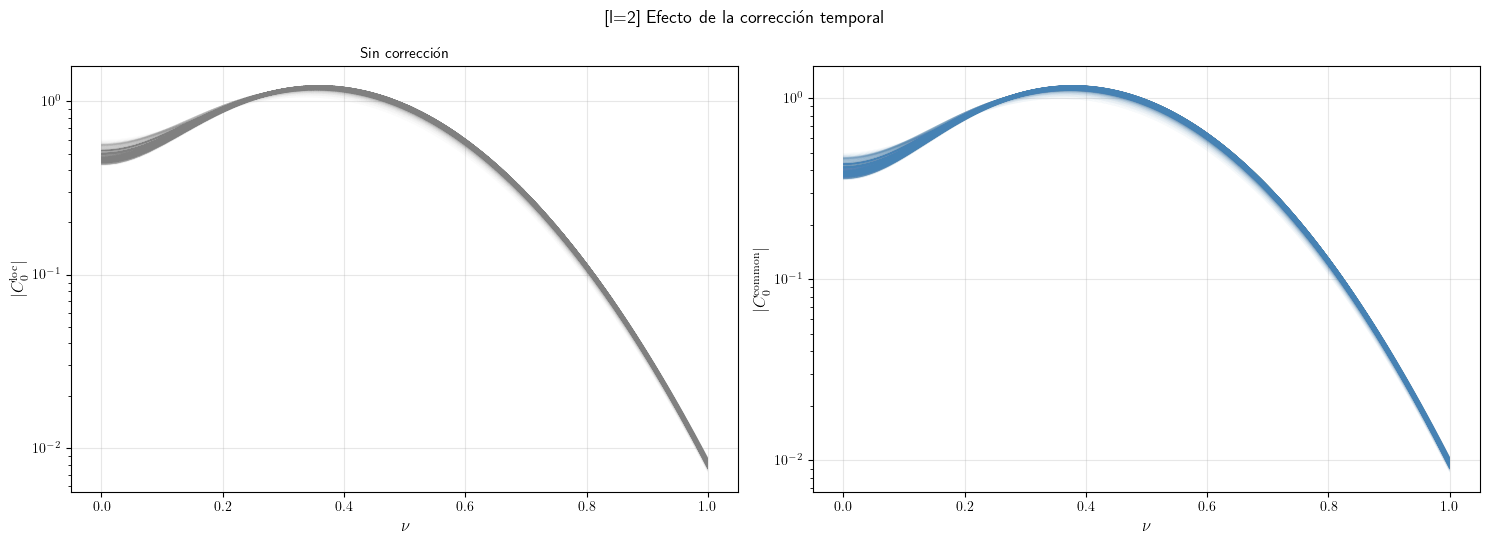


✓ Verificación gráfica completada.


In [ ]:
# ============================================================
# CELL 3 — WINDOW SCAN (l = 2) [OPTIMIZED]
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# WINDOW GRID
# ============================================================

t0_min_grid = np.arange(0, 45, 1)
t0_max_grid = np.arange(15, 75, 1)

# ------------------------------------------------------------
# Vectorized (MUCH faster than list comprehension)
# ------------------------------------------------------------
TMN, TMX = np.meshgrid(
    t0_min_grid,
    t0_max_grid,
    indexing='ij'
)

mask_valid = (
    (TMX > TMN) &
    ((TMX - TMN) >= 20)
)

tmn_arr = TMN[mask_valid].astype(float)
tmx_arr = TMX[mask_valid].astype(float)

duration_arr = tmx_arr - tmn_arr

n_windows = len(tmn_arr)

print(f"[l=2] Window pairs: {n_windows}")

# ============================================================
# TEMPORAL INFORMATION
# ============================================================

t_peak_array = np.array(
    [waveforms_l2[nu]['t_peak'] for nu in nu_grid_l2],
    dtype=float
)

t_peak_ref = np.mean(t_peak_array)

print(f"\n[l=2] Temporal information:")
print(f"  t_peak_ref = {t_peak_ref:.3f} [M]")
print(f"  t_peak range = [{t_peak_array.min():.3f}, {t_peak_array.max():.3f}]")
print(f"  Total variation = {(t_peak_array.max()-t_peak_array.min()):.3f} [M]")

omega_0 = omegas_l2[0]

print(f"\n[l=2] QNM frequency:")
print(f"  ω_0 = {omega_0.real:.6f} - i {abs(omega_0.imag):.6f}")

# ============================================================
# MATRICES
# ============================================================

abs_C0_matrix_l2 = np.full(
    (n_nu_l2, n_windows),
    np.nan,
    dtype=float
)

C0_complex_matrix_l2 = np.full(
    (n_nu_l2, n_windows),
    np.nan + 0j,
    dtype=complex
)

# ============================================================
# OPTIMIZED COMPUTATION
# ============================================================
#
# Improvements:
#
# 1) searchsorted instead of boolean masks
# 2) complex cumulative sums
# 3) O(1) per window
#
# ============================================================

for nu_idx, nu in enumerate(nu_grid_l2):

    f = fits_l2[nu]

    t0_arr = np.asarray(f['t0_arr'], dtype=float)

    C0_arr = np.asarray(
        f['C_matrix'][:, 0],
        dtype=complex
    )

    # --------------------------------------------------------
    # Complex cumulative sum
    # --------------------------------------------------------
    csum = np.concatenate([
        [0.0 + 0.0j],
        np.cumsum(C0_arr)
    ])

    # ========================================================
    # Fast indices for ALL windows
    # ========================================================

    i0 = np.searchsorted(t0_arr, tmn_arr, side='left')
    i1 = np.searchsorted(t0_arr, tmx_arr, side='right')

    counts = i1 - i0

    valid = counts > 0

    # --------------------------------------------------------
    # Vectorized complex mean
    # --------------------------------------------------------
    sums = csum[i1] - csum[i0]

    means = np.full(n_windows, np.nan + 0j, dtype=complex)

    means[valid] = sums[valid] / counts[valid]

    # --------------------------------------------------------
    # Store
    # --------------------------------------------------------
    C0_complex_matrix_l2[nu_idx, :] = means

    abs_C0_matrix_l2[nu_idx, :] = np.abs(means)

print(f"\n[l=2] Matrices constructed:")
print(f"  Shape = {abs_C0_matrix_l2.shape}")
print(f"  NaN fraction = {np.mean(np.isnan(abs_C0_matrix_l2)):.2%}")

# ============================================================
# TEMPORAL CORRECTION
# ============================================================

# ------------------------------------------------------------
# Fully vectorized
# ------------------------------------------------------------
phase_shifts = np.exp(
    1j * omega_0 * (t_peak_array - t_peak_ref)
)

C0_common_matrix_l2 = (
    C0_complex_matrix_l2 *
    phase_shifts[:, None]
)

print(f"\n[l=2] Temporal correction applied.")
print(f"  Common reference = t_peak_ref")

# ============================================================
# VERIFICATION
# ============================================================

fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(15, 5.5)
)

# ------------------------------------------------------------
# Panel 1
# ------------------------------------------------------------
ax1.plot(
    nu_grid_l2[:, None],
    abs_C0_matrix_l2,
    color='gray',
    alpha=0.05,
    lw=0.3
)

ax1.set_xlabel(r'$\nu$', fontsize=12)

ax1.set_ylabel(
    r'$|C_0^{\rm loc}|$',
    fontsize=12
)

ax1.set_title(
    r'Without correction',
    fontsize=11,
    fontweight='bold'
)

ax1.grid(alpha=0.3)

ax1.set_yscale('log')

# ------------------------------------------------------------
# Panel 2
# ------------------------------------------------------------
ax2.plot(
    nu_grid_l2[:, None],
    np.abs(C0_common_matrix_l2),
    color='steelblue',
    alpha=0.08,
    lw=0.3
)

ax2.set_xlabel(r'$\nu$', fontsize=12)

ax2.set_ylabel(
    r'$|C_0^{\rm common}|$',
    fontsize=12
)

ax2.grid(alpha=0.3)

ax2.set_yscale('log')

fig.suptitle(
    r'[l=2] Effect of the temporal correction',
    fontsize=13,
    fontweight='bold'
)

plt.tight_layout()

plt.show()

print("\n✓ Graphical verification completed.")

### new filtrado

[l=2] Filtrado: 1485 / 1485 ventanas (100.0%)
[l=2] Criterios: duración ≥ 20, t0_min ≥ 0, t0_max ≤ 75


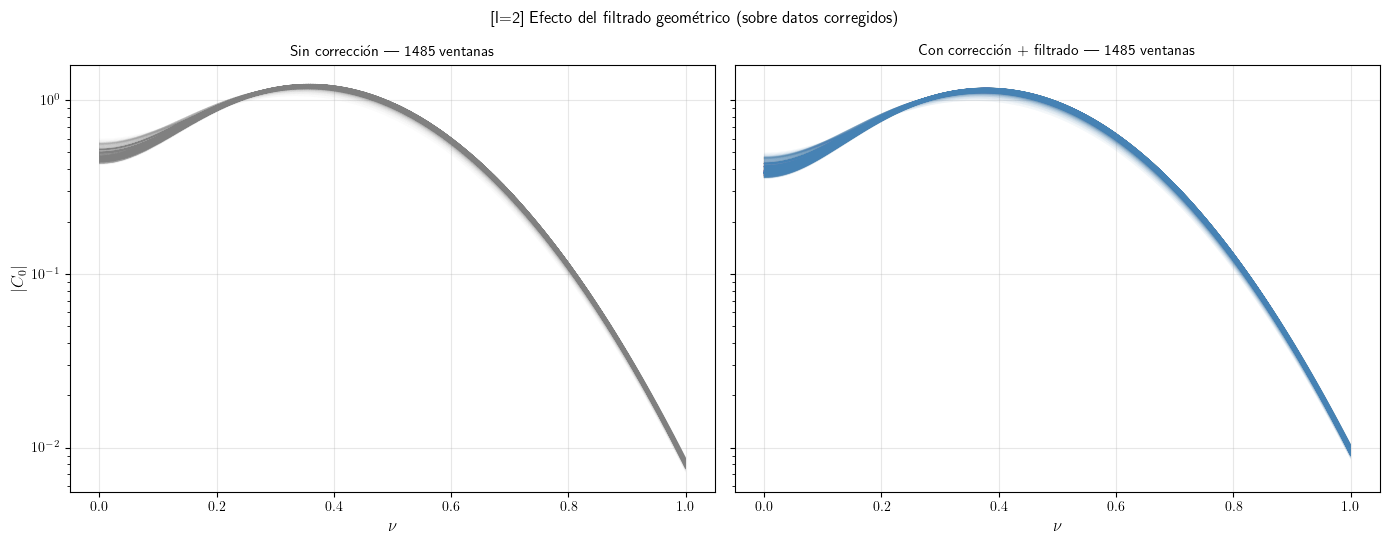


✓ Submatrices filtradas guardadas:
  abs_C0_filt_l2: shape (1001, 1485)
  C0_complex_filt_l2: shape (1001, 1485)


In [ ]:
# ============================================================
# CELL 4 — PHYSICAL WINDOW FILTERING (l = 2)
# ============================================================

# ---------- Filter thresholds ----------
MIN_DURATION = 20   # M
MIN_T0       = 0    # avoid prompt response
MAX_T1       = 75   # avoid late-time tail

# ---------- Geometric mask ----------
keep = (
    (duration_arr >= MIN_DURATION) &
    (tmn_arr      >= MIN_T0)       &
    (tmx_arr      <= MAX_T1)
)

# ---------- Additional filter: NaNs ----------
nan_frac_per_window = np.mean(np.isnan(np.abs(C0_common_matrix_l2)), axis=0)
keep &= (nan_frac_per_window < 0.05)

n_keep = int(keep.sum())

print(f"[l=2] Filtering: {n_keep} / {n_windows} windows ({n_keep/n_windows:.1%})")
print(f"[l=2] Criteria: duration ≥ {MIN_DURATION}, "
      f"t0_min ≥ {MIN_T0}, t0_max ≤ {MAX_T1}")

window_pairs_arr = np.column_stack([
    tmn_arr,
    tmx_arr
])

# ---------- Submatrices (USING CORRECTED VERSION) ----------
abs_C0_filt_l2     = np.abs(C0_common_matrix_l2[:, keep])
C0_complex_filt_l2 = C0_common_matrix_l2[:, keep]
window_pairs_filt_l2 = window_pairs_arr[keep]


# ============================================================
# Verification: cloud without correction vs with correction
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharey=True)

# --- Without correction (for reference) ---
ax = axes[0]
for w_idx in range(n_windows):
    ax.plot(nu_grid_l2, abs_C0_matrix_l2[:, w_idx],
            color='gray', alpha=0.05, lw=0.3)

ax.set_xlabel(r'$\nu$', fontsize=12)
ax.set_ylabel(r'$|C_0|$', fontsize=12)
ax.set_title(f'Without correction — {n_windows} windows', fontsize=11, fontweight='bold')
ax.grid(alpha=0.3)
ax.set_yscale('log')

# --- With correction and filtering ---
ax = axes[1]
for w_idx in range(abs_C0_filt_l2.shape[1]):
    ax.plot(nu_grid_l2, abs_C0_filt_l2[:, w_idx],
            color='steelblue', alpha=0.08, lw=0.4)

ax.set_xlabel(r'$\nu$', fontsize=12)
ax.set_title(f'With correction + filtering — {n_keep} windows', fontsize=11, fontweight='bold')
ax.grid(alpha=0.3)
ax.set_yscale('log')

fig.suptitle('[l=2] Effect of geometric filtering (on corrected data)', 
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\n✓ Filtered submatrices saved:")
print(f"  abs_C0_filt_l2: shape {abs_C0_filt_l2.shape}")
print(f"  C0_complex_filt_l2: shape {C0_complex_filt_l2.shape}")

### new statistics


[l=2] ESTADÍSTICOS DE EXCITACIÓN (datos corregidos):
  ω_0^R = 0.373672 [M^-1]
  ω_0^I = -0.088962 [M^-1]

  Pico de la mediana:
    ν_pico = 0.3780
    |C_0^common| = 1.145714
    Δν = ν_pico - ω_0^R = 0.004328
    Anchura banda 1σ en el pico: 0.036257 (3.16%)


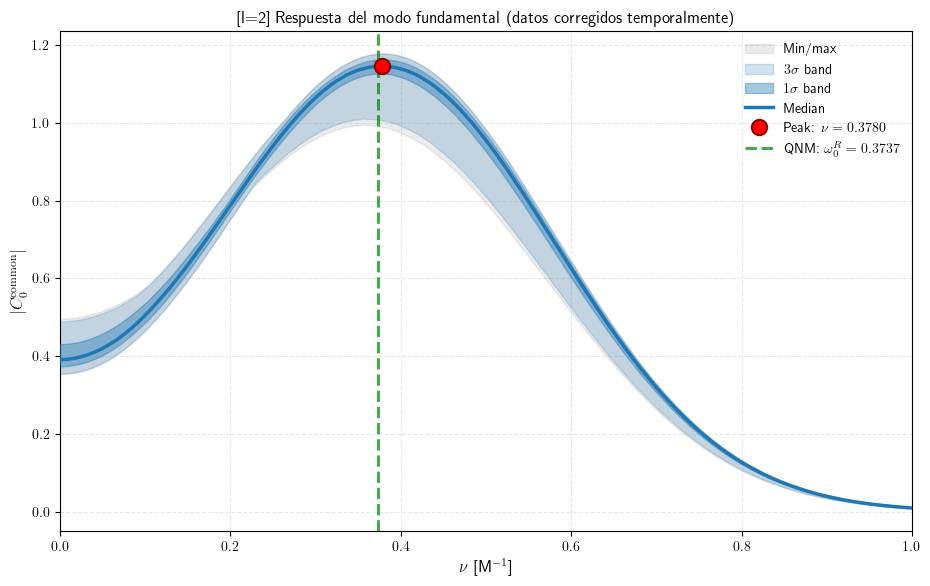


✓ Curva de resonancia guardada: resonancia_l2.png


In [ ]:
# ============================================================
# CELL 5 — STATISTICS (l = 2, as a function of nu)
# ============================================================
# Note: Using C0_common_matrix_l2 (temporally corrected)
plt.rcParams['text.usetex'] = True
median_C0_l2 = np.nanmedian(abs_C0_filt_l2, axis=1)

# 1sigma band (68.27%)
p1s_lo_l2 = np.nanpercentile(abs_C0_filt_l2, 15.865, axis=1)
p1s_hi_l2 = np.nanpercentile(abs_C0_filt_l2, 84.135, axis=1)

# 3sigma band (99.73%)
p3s_lo_l2 = np.nanpercentile(abs_C0_filt_l2,  0.135, axis=1)
p3s_hi_l2 = np.nanpercentile(abs_C0_filt_l2, 99.865, axis=1)

env_min_l2 = np.nanmin(abs_C0_filt_l2, axis=1)
env_max_l2 = np.nanmax(abs_C0_filt_l2, axis=1)

# ---------- Diagnostics ----------
idx_peak    = np.nanargmax(median_C0_l2)
peak_value  = median_C0_l2[idx_peak]
nu_peak     = nu_grid_l2[idx_peak]
band_width  = p1s_hi_l2[idx_peak] - p1s_lo_l2[idx_peak]

# Real QNM frequency (real part of ω_0)
nu_qnm = omega_0.real

print(f"\n[l=2] EXCITATION STATISTICS (corrected data):")
print(f"  ω_0^R = {nu_qnm:.6f} [M^-1]")
print(f"  ω_0^I = {omega_0.imag:.6f} [M^-1]")
print(f"\n  Median peak:")
print(f"    ν_peak = {nu_peak:.4f}")
print(f"    |C_0^common| = {peak_value:.6f}")
print(f"    Δν = ν_peak - ω_0^R = {(nu_peak - nu_qnm):.6f}")
print(f"    1σ band width at the peak: {band_width:.6f} ({band_width/peak_value*100:.2f}%)")


# ============================================================
# Final plot: Resonance curve
# ============================================================
fig, ax = plt.subplots(figsize=(11, 6.5))

# Total envelope
ax.fill_between(nu_grid_l2, env_min_l2, env_max_l2,
                color='gray', alpha=0.15, zorder=1,
                label='Min/max')

# 3sigma band
ax.fill_between(nu_grid_l2, p3s_lo_l2, p3s_hi_l2,
                color='C0', alpha=0.20, zorder=2,
                label=r'$3\sigma$ band')

# 1sigma band
ax.fill_between(nu_grid_l2, p1s_lo_l2, p1s_hi_l2,
                color='C0', alpha=0.40, zorder=3,
                label=r'$1\sigma$ band')

# Median
ax.plot(nu_grid_l2, median_C0_l2,
        color='C0', lw=2.5, zorder=4,
        label='Median')

# Mark experimental peak
ax.plot(nu_peak, peak_value, 'o', 
        color='darkred', markersize=11, zorder=5, markeredgewidth=1.5,
        markeredgecolor='darkred', markerfacecolor='red',
        label=fr'Peak: $\nu = {nu_peak:.4f}$')

# Mark theoretical QNM frequency
ax.axvline(nu_qnm, color='green', linestyle='--', lw=2.2, alpha=0.7, zorder=3,
           label=fr'QNM: $\omega_0^R = {nu_qnm:.4f}$')

ax.set_xlabel(r'$\nu$ [M$^{-1}$]', fontsize=12)
ax.set_ylabel(r'$|C_0^{\mathrm{common}}|$', fontsize=12)
ax.set_title(r'[l=2] Fundamental mode response (temporally corrected data)', 
             fontsize=12, fontweight='bold')
ax.grid(alpha=0.3, linestyle='--')
ax.legend(frameon=False, fontsize=10, loc='upper right')
ax.set_xlim(nu_grid_l2.min(), nu_grid_l2.max())

#plt.tight_layout()
#plt.savefig('resonancia_l2.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✓ Resonance curve saved: resonancia_l2.png")


[l=2] COMPARACIÓN DE PICOS:
  ω_0^R = 0.373672 [M^-1]

  SIN CORRECCIÓN temporal:
    ν_pico = 0.3570
    |C_0| = 1.207050
    Δν = -0.016672

  CON CORRECCIÓN temporal:
    ν_pico = 0.3780
    |C_0^common| = 1.145714
    Δν = 0.004328

  Desplazamiento del pico: -0.021000


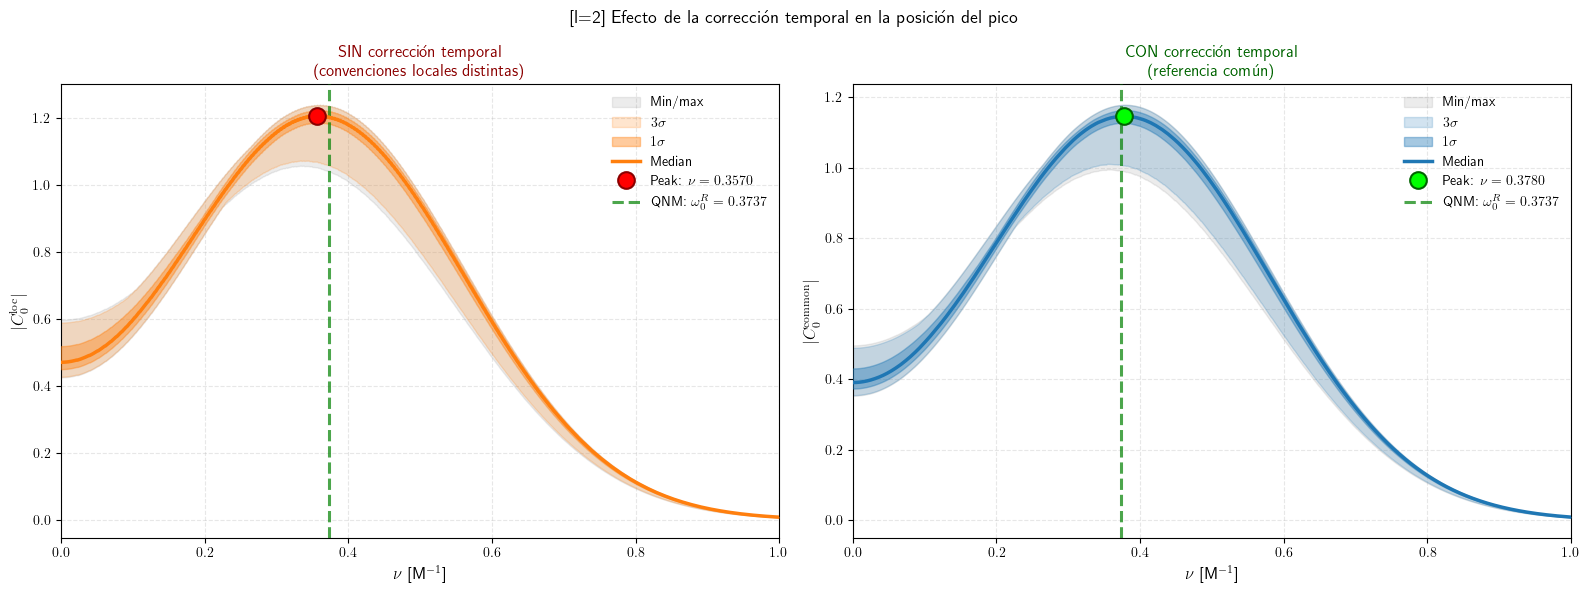


✓ Comparación guardada: comparacion_picos_l2.png


In [ ]:
# ============================================================
# CELL 5B — COMPARISON: WITHOUT CORRECTION vs WITH CORRECTION
# ============================================================

# Statistics from the UNCORRECTED MATRIX
abs_C0_unfilt_l2 = abs_C0_matrix_l2  # full raw matrix

median_C0_uncorr = np.nanmedian(abs_C0_unfilt_l2, axis=1)
p1s_lo_uncorr = np.nanpercentile(abs_C0_unfilt_l2, 15.865, axis=1)
p1s_hi_uncorr = np.nanpercentile(abs_C0_unfilt_l2, 84.135, axis=1)
p3s_lo_uncorr = np.nanpercentile(abs_C0_unfilt_l2,  0.135, axis=1)
p3s_hi_uncorr = np.nanpercentile(abs_C0_unfilt_l2, 99.865, axis=1)
env_min_uncorr = np.nanmin(abs_C0_unfilt_l2, axis=1)
env_max_uncorr = np.nanmax(abs_C0_unfilt_l2, axis=1)

# Peak in UNCORRECTED data
idx_peak_uncorr = np.nanargmax(median_C0_uncorr)
nu_peak_uncorr = nu_grid_l2[idx_peak_uncorr]
peak_value_uncorr = median_C0_uncorr[idx_peak_uncorr]

# Peak in CORRECTED data (already computed in CELL 5)
# idx_peak, nu_peak, peak_value are already defined

# Theoretical QNM frequency
nu_qnm = omega_0.real

print(f"\n[l=2] PEAK COMPARISON:")
print(f"  ω_0^R = {nu_qnm:.6f} [M^-1]")
print(f"\n  WITHOUT temporal correction:")
print(f"    ν_peak = {nu_peak_uncorr:.4f}")
print(f"    |C_0| = {peak_value_uncorr:.6f}")
print(f"    Δν = {(nu_peak_uncorr - nu_qnm):.6f}")
print(f"\n  WITH temporal correction:")
print(f"    ν_peak = {nu_peak:.4f}")
print(f"    |C_0^common| = {peak_value:.6f}")
print(f"    Δν = {(nu_peak - nu_qnm):.6f}")
print(f"\n  Peak shift: {(nu_peak_uncorr - nu_peak):.6f}")


# ============================================================
# Side-by-side comparison plot
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --------- LEFT PANEL: WITHOUT CORRECTION ---------
ax = axes[0]

# Envelopes
ax.fill_between(nu_grid_l2, env_min_uncorr, env_max_uncorr,
                color='gray', alpha=0.15, zorder=1, label='Min/max')
ax.fill_between(nu_grid_l2, p3s_lo_uncorr, p3s_hi_uncorr,
                color='C1', alpha=0.20, zorder=2, label=r'$3\sigma$')
ax.fill_between(nu_grid_l2, p1s_lo_uncorr, p1s_hi_uncorr,
                color='C1', alpha=0.40, zorder=3, label=r'$1\sigma$')

# Median
ax.plot(nu_grid_l2, median_C0_uncorr,
        color='C1', lw=2.5, zorder=4, label='Median')

# Experimental peak
ax.plot(nu_peak_uncorr, peak_value_uncorr, 'o',
        color='darkred', markersize=12, zorder=5, markeredgewidth=1.5,
        markeredgecolor='darkred', markerfacecolor='red',
        label=fr'Peak: $\nu = {nu_peak_uncorr:.4f}$')

# Theoretical QNM
ax.axvline(nu_qnm, color='green', linestyle='--', lw=2.2, alpha=0.7, zorder=3,
           label=fr'QNM: $\omega_0^R = {nu_qnm:.4f}$')

ax.set_xlabel(r'$\nu$ [M$^{-1}$]', fontsize=12)
ax.set_ylabel(r'$|C_0^{\rm loc}|$', fontsize=12)
ax.set_title('WITHOUT temporal correction\n(different local conventions)', 
             fontsize=12, fontweight='bold', color='darkred')
ax.grid(alpha=0.3, linestyle='--')
ax.legend(frameon=False, fontsize=10, loc='upper right')
ax.set_xlim(nu_grid_l2.min(), nu_grid_l2.max())


# --------- RIGHT PANEL: WITH CORRECTION ---------
ax = axes[1]

# Envelopes (from filtered corrected data)
ax.fill_between(nu_grid_l2, env_min_l2, env_max_l2,
                color='gray', alpha=0.15, zorder=1, label='Min/max')
ax.fill_between(nu_grid_l2, p3s_lo_l2, p3s_hi_l2,
                color='C0', alpha=0.20, zorder=2, label=r'$3\sigma$')
ax.fill_between(nu_grid_l2, p1s_lo_l2, p1s_hi_l2,
                color='C0', alpha=0.40, zorder=3, label=r'$1\sigma$')

# Median
ax.plot(nu_grid_l2, median_C0_l2,
        color='C0', lw=2.5, zorder=4, label='Median')

# Experimental peak
ax.plot(nu_peak, peak_value, 'o',
        color='darkgreen', markersize=12, zorder=5, markeredgewidth=1.5,
        markeredgecolor='darkgreen', markerfacecolor='lime',
        label=fr'Peak: $\nu = {nu_peak:.4f}$')

# Theoretical QNM
ax.axvline(nu_qnm, color='green', linestyle='--', lw=2.2, alpha=0.7, zorder=3,
           label=fr'QNM: $\omega_0^R = {nu_qnm:.4f}$')

ax.set_xlabel(r'$\nu$ [M$^{-1}$]', fontsize=12)
ax.set_ylabel(r'$|C_0^{\rm common}|$', fontsize=12)
ax.set_title('WITH temporal correction\n(common reference frame)', 
             fontsize=12, fontweight='bold', color='darkgreen')
ax.grid(alpha=0.3, linestyle='--')
ax.legend(frameon=False, fontsize=10, loc='upper right')
ax.set_xlim(nu_grid_l2.min(), nu_grid_l2.max())

fig.suptitle(r'[l=2] Effect of temporal correction on the peak position', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
#plt.savefig('comparacion_picos_l2.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✓ Comparison saved: comparacion_picos_l2.png")

In [ ]:
# Copy uncorrected statistics from CELL 5B
# (make sure CELL 5B has been executed beforehand)
if 'median_C0_uncorr' not in locals():
    median_C0_uncorr = np.nanmedian(abs_C0_matrix_l2, axis=1)
    p1s_lo_uncorr = np.nanpercentile(abs_C0_matrix_l2, 15.865, axis=1)
    p1s_hi_uncorr = np.nanpercentile(abs_C0_matrix_l2, 84.135, axis=1)
    p3s_lo_uncorr = np.nanpercentile(abs_C0_matrix_l2,  0.135, axis=1)
    p3s_hi_uncorr = np.nanpercentile(abs_C0_matrix_l2, 99.865, axis=1)
    env_min_uncorr = np.nanmin(abs_C0_matrix_l2, axis=1)
    env_max_uncorr = np.nanmax(abs_C0_matrix_l2, axis=1)

### old fase

[l=2] Fase en el pico de |C_0| (nu = 0.3780):
  phi = -2.2848 rad  (-130.91 deg)
  Anchura banda 1sigma en el pico: 0.1271 rad  (7.29 deg)


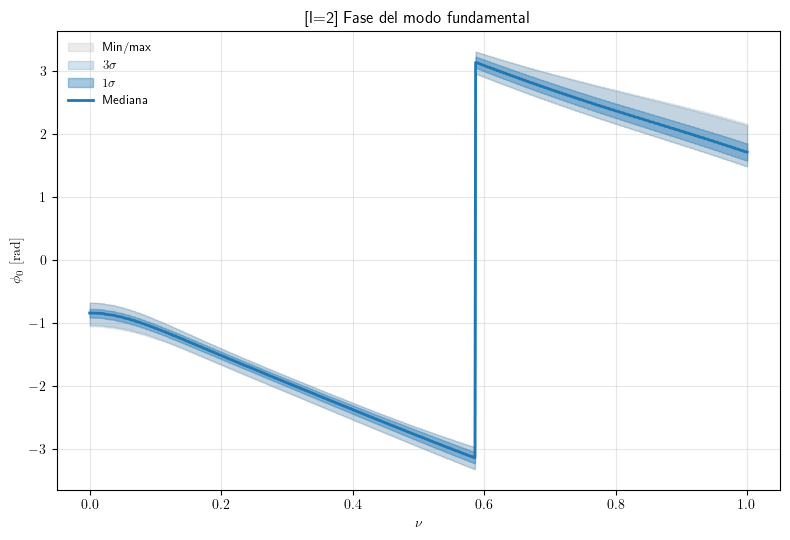

In [ ]:
# ============================================================
# CELL 5b — PHASE STATISTICS (l = 2, as a function of nu)
# ============================================================
# We apply the same methodology (median + 1sigma + 3sigma) to the
# phase of the complex estimator <C_0>_w.
#
# To avoid issues with phase periodicity, we work around a reference
# value (the median phase at each nu) and then apply percentiles to
# the "unwrapped" difference over the range (-pi, pi]. This is stable
# unless the true phase dispersion at fixed nu spans the full circle
# (which should not happen).
# ============================================================

# Filter the complex matrix using the same criterion as in cell 4
# (assuming you applied the same mask as for abs_C0_matrix_l2)
# If not, and you want to use the raw matrix directly:
C0_complex_filt_l2 = C0_complex_matrix_l2  # change this if filtered


# ---------- Helper: circular percentiles ----------
def circ_stats(M):
    """
    Circular phase statistics from a complex matrix
    M with shape (n_nu, n_windows).

    Returns the median phase and the 1sigma/3sigma percentiles computed
    from the wrapped residual (-pi, pi] relative to the median, in order
    to avoid artifacts from the +/- pi discontinuity.

    Output is in radians.
    """
    phases = np.angle(M)  # shape (n_nu, n_windows), values in (-pi, pi]

    # Circular median: argument of the complex mean
    mean_complex = np.nanmean(M, axis=1)
    phi_med = np.angle(mean_complex)  # shape (n_nu,)

    # Difference relative to the median, wrapped into (-pi, pi]
    delta = np.angle(np.exp(1j * (phases - phi_med[:, None])))

    # Residual percentiles
    d_p1s_lo = np.nanpercentile(delta, 15.865, axis=1)
    d_p1s_hi = np.nanpercentile(delta, 84.135, axis=1)
    d_p3s_lo = np.nanpercentile(delta,  0.135, axis=1)
    d_p3s_hi = np.nanpercentile(delta, 99.865, axis=1)

    d_env_lo = np.nanmin(delta, axis=1)
    d_env_hi = np.nanmax(delta, axis=1)

    # Return to the absolute scale (adding the median)
    return {
        'med':     phi_med,
        'p1s_lo':  phi_med + d_p1s_lo,
        'p1s_hi':  phi_med + d_p1s_hi,
        'p3s_lo':  phi_med + d_p3s_lo,
        'p3s_hi':  phi_med + d_p3s_hi,
        'env_lo':  phi_med + d_env_lo,
        'env_hi':  phi_med + d_env_hi,
    }


phase_stats_l2 = circ_stats(C0_complex_filt_l2)


# ---------- Diagnostics ----------
idx_peak  = np.nanargmax(median_C0_l2)  # same nu as the |C_0| peak
phi_peak  = phase_stats_l2['med'][idx_peak]
band_pk   = phase_stats_l2['p1s_hi'][idx_peak] - phase_stats_l2['p1s_lo'][idx_peak]

print(f"[l=2] Phase at the |C_0| peak (nu = {nu_grid_l2[idx_peak]:.4f}):")
print(f"  phi = {phi_peak:.4f} rad  ({np.degrees(phi_peak):.2f} deg)")
print(f"  1sigma band width at the peak: {band_pk:.4f} rad  "
      f"({np.degrees(band_pk):.2f} deg)")


# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 5.5))

ax.fill_between(nu_grid_l2, phase_stats_l2['env_lo'], phase_stats_l2['env_hi'],
                color='gray', alpha=0.15, zorder=1, label='Min/max')

ax.fill_between(nu_grid_l2, phase_stats_l2['p3s_lo'], phase_stats_l2['p3s_hi'],
                color='C0', alpha=0.20, zorder=2, label=r'$3\sigma$')

ax.fill_between(nu_grid_l2, phase_stats_l2['p1s_lo'], phase_stats_l2['p1s_hi'],
                color='C0', alpha=0.40, zorder=3, label=r'$1\sigma$')

ax.plot(nu_grid_l2, phase_stats_l2['med'],
        color='C0', lw=2.0, zorder=4, label='Median')

ax.set_xlabel(r'$\nu$')
ax.set_ylabel(r'$\phi_0\ \mathrm{[rad]}$')
ax.set_title(r'[l=2] Phase of the fundamental mode')
ax.grid(alpha=0.3)
ax.legend(frameon=False, fontsize=9)
plt.tight_layout()
plt.show()

[l=2] Estadísticos de fase (comparación):

  En el pico (ν = 0.3780):

  SIN corrección:
    φ = -2.2848 rad  (-130.91°)
    Anchura 1σ: 0.1271 rad  (7.29°)

  CON corrección:
    φ = -2.4776 rad  (-141.96°)
    Anchura 1σ: 0.1271 rad  (7.29°)

  Diferencia de fase: -0.1928 rad  (-11.05°)


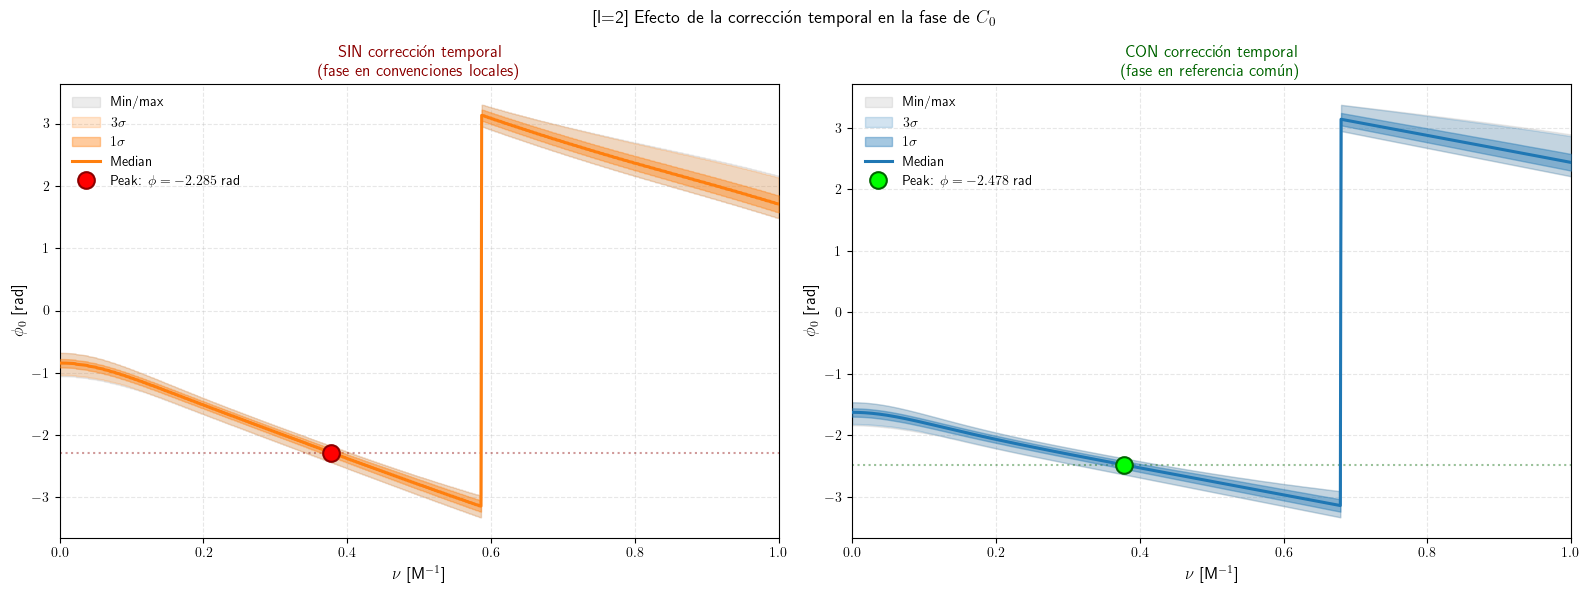


✓ Comparación de fase guardada: comparacion_fase_l2.png


In [ ]:
# ============================================================
# CELL 5b — PHASE COMPARISON (l = 2)
# ============================================================
# Phase statistics comparing:
# - Without correction: C0_complex_matrix_l2[:, keep]
# - With correction: C0_common_matrix_l2[:, keep]

print(f"[l=2] Phase statistics (comparison):")


# ---------- Helper: circular percentiles ----------
def circ_stats(M):
    """
    Circular phase statistics from a complex matrix
    M with shape (n_nu, n_windows).

    Returns the median phase and the 1sigma/3sigma percentiles computed
    from the wrapped residual (-pi, pi] relative to the median.

    Output is in radians.
    """
    phases = np.angle(M)  # shape (n_nu, n_windows), values in (-pi, pi]

    # Circular median: argument of the complex mean
    mean_complex = np.nanmean(M, axis=1)
    phi_med = np.angle(mean_complex)  # shape (n_nu,)

    # Difference relative to the median, wrapped into (-pi, pi]
    delta = np.angle(np.exp(1j * (phases - phi_med[:, None])))

    # Residual percentiles
    d_p1s_lo = np.nanpercentile(delta, 15.865, axis=1)
    d_p1s_hi = np.nanpercentile(delta, 84.135, axis=1)
    d_p3s_lo = np.nanpercentile(delta,  0.135, axis=1)
    d_p3s_hi = np.nanpercentile(delta, 99.865, axis=1)

    d_env_lo = np.nanmin(delta, axis=1)
    d_env_hi = np.nanmax(delta, axis=1)

    # Return to the absolute scale (adding the median)
    return {
        'med':     phi_med,
        'p1s_lo':  phi_med + d_p1s_lo,
        'p1s_hi':  phi_med + d_p1s_hi,
        'p3s_lo':  phi_med + d_p3s_lo,
        'p3s_hi':  phi_med + d_p3s_hi,
        'env_lo':  phi_med + d_env_lo,
        'env_hi':  phi_med + d_env_hi,
    }


# Matrices to compare
C0_uncorr_filt = C0_complex_matrix_l2[:, keep]      # WITHOUT correction, filtered
C0_corr_filt = C0_common_matrix_l2[:, keep]         # WITH correction, filtered

# Statistics
phase_stats_uncorr = circ_stats(C0_uncorr_filt)
phase_stats_corr = circ_stats(C0_corr_filt)

# Peak (same nu for both)
idx_peak = np.nanargmax(median_C0_l2)
nu_peak_val = nu_grid_l2[idx_peak]

phi_peak_uncorr = phase_stats_uncorr['med'][idx_peak]
band_pk_uncorr = phase_stats_uncorr['p1s_hi'][idx_peak] - phase_stats_uncorr['p1s_lo'][idx_peak]

phi_peak_corr = phase_stats_corr['med'][idx_peak]
band_pk_corr = phase_stats_corr['p1s_hi'][idx_peak] - phase_stats_corr['p1s_lo'][idx_peak]

print(f"\n  At the peak (ν = {nu_peak_val:.4f}):")
print(f"\n  WITHOUT correction:")
print(f"    φ = {phi_peak_uncorr:.4f} rad  ({np.degrees(phi_peak_uncorr):.2f}°)")
print(f"    1σ width: {band_pk_uncorr:.4f} rad  ({np.degrees(band_pk_uncorr):.2f}°)")
print(f"\n  WITH correction:")
print(f"    φ = {phi_peak_corr:.4f} rad  ({np.degrees(phi_peak_corr):.2f}°)")
print(f"    1σ width: {band_pk_corr:.4f} rad  ({np.degrees(band_pk_corr):.2f}°)")
print(f"\n  Phase difference: {(phi_peak_corr - phi_peak_uncorr):.4f} rad  "
      f"({np.degrees(phi_peak_corr - phi_peak_uncorr):.2f}°)")


# ============================================================
# Side-by-side comparison plot
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --------- LEFT PANEL: WITHOUT CORRECTION ---------
ax = axes[0]

ax.fill_between(nu_grid_l2, phase_stats_uncorr['env_lo'], phase_stats_uncorr['env_hi'],
                color='gray', alpha=0.15, zorder=1, label='Min/max')

ax.fill_between(nu_grid_l2, phase_stats_uncorr['p3s_lo'], phase_stats_uncorr['p3s_hi'],
                color='C1', alpha=0.20, zorder=2, label=r'$3\sigma$')

ax.fill_between(nu_grid_l2, phase_stats_uncorr['p1s_lo'], phase_stats_uncorr['p1s_hi'],
                color='C1', alpha=0.40, zorder=3, label=r'$1\sigma$')

ax.plot(nu_grid_l2, phase_stats_uncorr['med'],
        color='C1', lw=2.2, zorder=4, label='Median')

ax.plot(nu_peak_val, phi_peak_uncorr, 'o',
        color='darkred', markersize=12, zorder=5, markeredgewidth=1.5,
        markeredgecolor='darkred', markerfacecolor='red',
        label=fr'Peak: $\phi = {phi_peak_uncorr:.3f}$ rad')

ax.axhline(phi_peak_uncorr, color='darkred', linestyle=':', alpha=0.4, lw=1.5)

ax.set_xlabel(r'$\nu$ [M$^{-1}$]', fontsize=12)
ax.set_ylabel(r'$\phi_0$ [rad]', fontsize=12)
ax.set_title('WITHOUT temporal correction\n(phase in local conventions)', 
             fontsize=12, fontweight='bold', color='darkred')
ax.grid(alpha=0.3, linestyle='--')
ax.legend(frameon=False, fontsize=10, loc='best')
ax.set_xlim(nu_grid_l2.min(), nu_grid_l2.max())


# --------- RIGHT PANEL: WITH CORRECTION ---------
ax = axes[1]

ax.fill_between(nu_grid_l2, phase_stats_corr['env_lo'], phase_stats_corr['env_hi'],
                color='gray', alpha=0.15, zorder=1, label='Min/max')

ax.fill_between(nu_grid_l2, phase_stats_corr['p3s_lo'], phase_stats_corr['p3s_hi'],
                color='C0', alpha=0.20, zorder=2, label=r'$3\sigma$')

ax.fill_between(nu_grid_l2, phase_stats_corr['p1s_lo'], phase_stats_corr['p1s_hi'],
                color='C0', alpha=0.40, zorder=3, label=r'$1\sigma$')

ax.plot(nu_grid_l2, phase_stats_corr['med'],
        color='C0', lw=2.2, zorder=4, label='Median')

ax.plot(nu_peak_val, phi_peak_corr, 'o',
        color='darkgreen', markersize=12, zorder=5, markeredgewidth=1.5,
        markeredgecolor='darkgreen', markerfacecolor='lime',
        label=fr'Peak: $\phi = {phi_peak_corr:.3f}$ rad')

ax.axhline(phi_peak_corr, color='darkgreen', linestyle=':', alpha=0.4, lw=1.5)

ax.set_xlabel(r'$\nu$ [M$^{-1}$]', fontsize=12)
ax.set_ylabel(r'$\phi_0$ [rad]', fontsize=12)
ax.set_title('WITH temporal correction\n(phase in a common reference frame)', 
             fontsize=12, fontweight='bold', color='darkgreen')
ax.grid(alpha=0.3, linestyle='--')
ax.legend(frameon=False, fontsize=10, loc='best')
ax.set_xlim(nu_grid_l2.min(), nu_grid_l2.max())

fig.suptitle(r'[l=2] Effect of temporal correction on the phase of $C_0$', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('comparacion_fase_l2.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✓ Phase comparison saved: comparacion_fase_l2.png")

[l=2] Fase en el pico de |C_0| (nu = 0.3780):
  phi = -2.2848 rad  (-130.91 deg)
  Anchura banda 1sigma en el pico: 0.1271 rad  (7.29 deg)


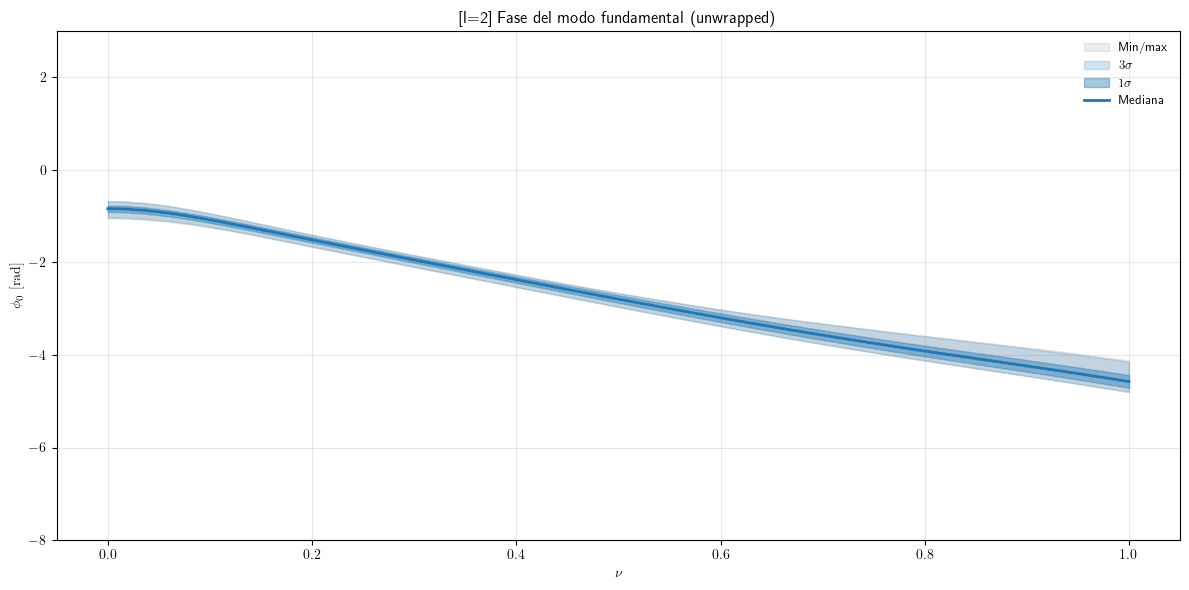

In [ ]:
# ============================================================
# CELL 5b — PHASE STATISTICS (l = 2, as a function of nu)
# ============================================================

C0_complex_filt_l2 = C0_complex_matrix_l2  # change this if filtered


def circ_stats(M):
    """
    Circular phase statistics from a complex matrix
    M with shape (n_nu, n_windows).
    """
    phases = np.angle(M)

    mean_complex = np.nanmean(M, axis=1)
    phi_med = np.angle(mean_complex)

    delta = np.angle(np.exp(1j * (phases - phi_med[:, None])))

    d_p1s_lo = np.nanpercentile(delta, 15.865, axis=1)
    d_p1s_hi = np.nanpercentile(delta, 84.135, axis=1)
    d_p3s_lo = np.nanpercentile(delta,  0.135, axis=1)
    d_p3s_hi = np.nanpercentile(delta, 99.865, axis=1)

    d_env_lo = np.nanmin(delta, axis=1)
    d_env_hi = np.nanmax(delta, axis=1)

    return {
        'med':     phi_med,
        'p1s_lo':  phi_med + d_p1s_lo,
        'p1s_hi':  phi_med + d_p1s_hi,
        'p3s_lo':  phi_med + d_p3s_lo,
        'p3s_hi':  phi_med + d_p3s_hi,
        'env_lo':  phi_med + d_env_lo,
        'env_hi':  phi_med + d_env_hi,
    }


phase_stats_l2 = circ_stats(C0_complex_filt_l2)


# ============================================================
# PHASE UNWRAP (remove 2pi jumps)
# ============================================================
# We apply unwrap to the median and propagate the same cumulative
# offset to the bands so they follow the central curve.
# ============================================================

med_unwrapped = np.unwrap(phase_stats_l2['med'])
offset = med_unwrapped - phase_stats_l2['med']  # multiples of 2pi

phase_stats_l2_uw = {
    'med':    med_unwrapped,
    'p1s_lo': phase_stats_l2['p1s_lo'] + offset,
    'p1s_hi': phase_stats_l2['p1s_hi'] + offset,
    'p3s_lo': phase_stats_l2['p3s_lo'] + offset,
    'p3s_hi': phase_stats_l2['p3s_hi'] + offset,
    'env_lo': phase_stats_l2['env_lo'] + offset,
    'env_hi': phase_stats_l2['env_hi'] + offset,
}


# ---------- Diagnostics ----------
idx_peak  = np.nanargmax(median_C0_l2)
phi_peak  = phase_stats_l2_uw['med'][idx_peak]
band_pk   = phase_stats_l2_uw['p1s_hi'][idx_peak] - phase_stats_l2_uw['p1s_lo'][idx_peak]

print(f"[l=2] Phase at the |C_0| peak (nu = {nu_grid_l2[idx_peak]:.4f}):")
print(f"  phi = {phi_peak:.4f} rad  ({np.degrees(phi_peak):.2f} deg)")
print(f"  1sigma band width at the peak: {band_pk:.4f} rad  "
      f"({np.degrees(band_pk):.2f} deg)")


# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 6))

ax.fill_between(nu_grid_l2, phase_stats_l2_uw['env_lo'], phase_stats_l2_uw['env_hi'],
                color='gray', alpha=0.15, zorder=1, label='Min/max')

ax.fill_between(nu_grid_l2, phase_stats_l2_uw['p3s_lo'], phase_stats_l2_uw['p3s_hi'],
                color='C0', alpha=0.20, zorder=2, label=r'$3\sigma$')

ax.fill_between(nu_grid_l2, phase_stats_l2_uw['p1s_lo'], phase_stats_l2_uw['p1s_hi'],
                color='C0', alpha=0.40, zorder=3, label=r'$1\sigma$')

ax.plot(nu_grid_l2, phase_stats_l2_uw['med'],
        color='C0', lw=2.0, zorder=4, label='Median')

ax.set_xlabel(r'$\nu$')
ax.set_ylabel(r'$\phi_0\ \mathrm{[rad]}$')
ax.set_title(r'[l=2] Phase of the fundamental mode (unwrapped)')
ax.set_ylim(-8,3)
ax.grid(alpha=0.3)
ax.legend(frameon=False, fontsize=9)
plt.tight_layout()
plt.show()

[l=2] Estadísticos de fase con unwrap:

  En el pico (ν = 0.3780):

  SIN corrección:
    φ = -2.2848 rad  (-130.91°)
    Anchura 1σ: 0.1271 rad  (7.29°)

  CON corrección:
    φ = -2.4776 rad  (-141.96°)
    Anchura 1σ: 0.1271 rad  (7.29°)

  Diferencia de fase: -0.1928 rad  (-11.05°)


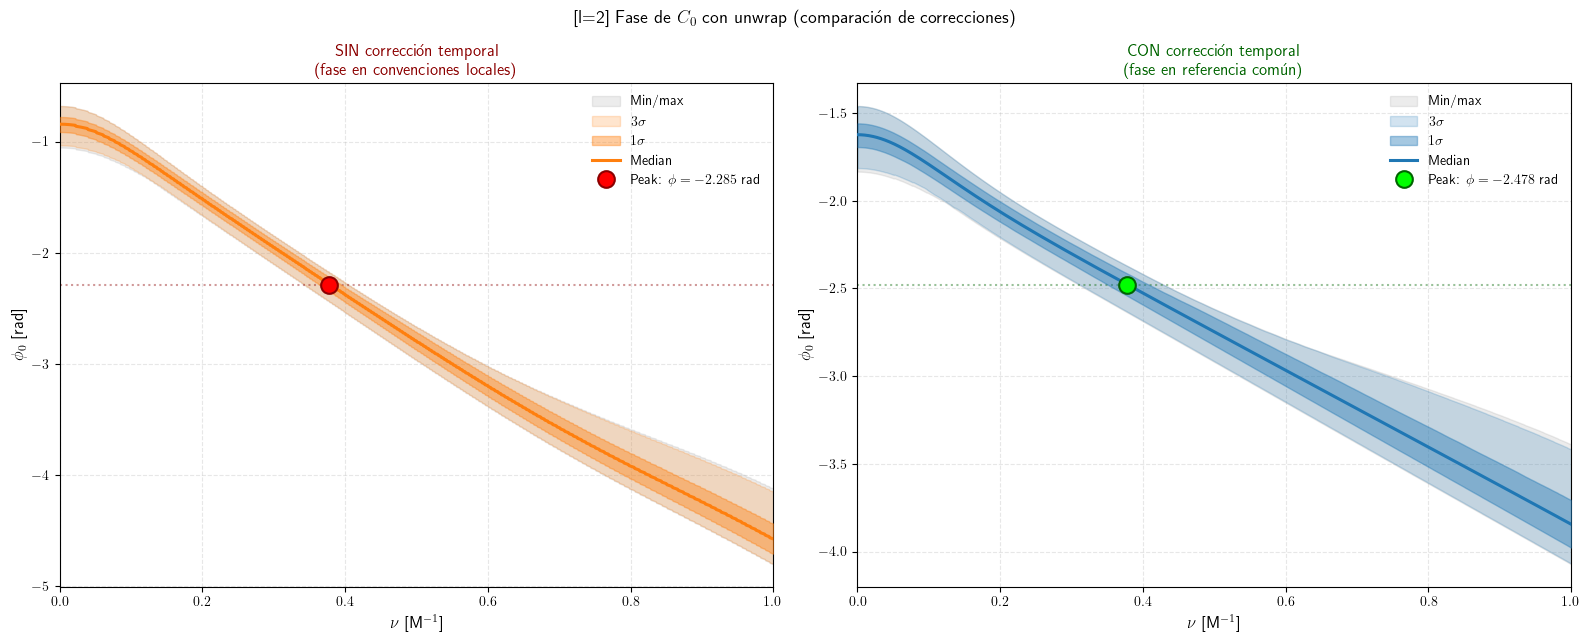


✓ Gráfica guardada: fase_unwrapped_comparacion_l2.png


In [ ]:
# ============================================================
# CELL 5b — PHASE STATISTICS WITH UNWRAP (l = 2)
# ============================================================
# Side-by-side comparison:
# - WITHOUT correction: C0_complex_matrix_l2 (raw, unfiltered)
# - WITH correction: C0_common_matrix_l2 (raw, unfiltered)
#
# We apply unwrap to remove ±π jumps

print(f"[l=2] Phase statistics with unwrap:")


def circ_stats(M):
    """
    Circular phase statistics from a complex matrix
    M with shape (n_nu, n_windows).
    """
    phases = np.angle(M)

    mean_complex = np.nanmean(M, axis=1)
    phi_med = np.angle(mean_complex)

    delta = np.angle(np.exp(1j * (phases - phi_med[:, None])))

    d_p1s_lo = np.nanpercentile(delta, 15.865, axis=1)
    d_p1s_hi = np.nanpercentile(delta, 84.135, axis=1)
    d_p3s_lo = np.nanpercentile(delta,  0.135, axis=1)
    d_p3s_hi = np.nanpercentile(delta, 99.865, axis=1)

    d_env_lo = np.nanmin(delta, axis=1)
    d_env_hi = np.nanmax(delta, axis=1)

    return {
        'med':     phi_med,
        'p1s_lo':  phi_med + d_p1s_lo,
        'p1s_hi':  phi_med + d_p1s_hi,
        'p3s_lo':  phi_med + d_p3s_lo,
        'p3s_hi':  phi_med + d_p3s_hi,
        'env_lo':  phi_med + d_env_lo,
        'env_hi':  phi_med + d_env_hi,
    }


def apply_unwrap(phase_stats_dict):
    """
    Apply unwrap to the median and propagate the cumulative offset
    to all bands in order to preserve consistency.
    """
    med_unwrapped = np.unwrap(phase_stats_dict['med'])
    offset = med_unwrapped - phase_stats_dict['med']  # multiples of 2π

    return {
        'med':    med_unwrapped,
        'p1s_lo': phase_stats_dict['p1s_lo'] + offset,
        'p1s_hi': phase_stats_dict['p1s_hi'] + offset,
        'p3s_lo': phase_stats_dict['p3s_lo'] + offset,
        'p3s_hi': phase_stats_dict['p3s_hi'] + offset,
        'env_lo': phase_stats_dict['env_lo'] + offset,
        'env_hi': phase_stats_dict['env_hi'] + offset,
    }


# Matrices to compare
C0_uncorr = C0_complex_matrix_l2  # WITHOUT correction
C0_corr = C0_common_matrix_l2     # WITH correction

# Circular statistics
phase_stats_uncorr = circ_stats(C0_uncorr)
phase_stats_corr = circ_stats(C0_corr)

# Apply unwrap
phase_stats_uncorr_uw = apply_unwrap(phase_stats_uncorr)
phase_stats_corr_uw = apply_unwrap(phase_stats_corr)

# Peak
idx_peak = np.nanargmax(median_C0_l2)
nu_peak_val = nu_grid_l2[idx_peak]

phi_peak_uncorr = phase_stats_uncorr_uw['med'][idx_peak]
band_pk_uncorr = phase_stats_uncorr_uw['p1s_hi'][idx_peak] - phase_stats_uncorr_uw['p1s_lo'][idx_peak]

phi_peak_corr = phase_stats_corr_uw['med'][idx_peak]
band_pk_corr = phase_stats_corr_uw['p1s_hi'][idx_peak] - phase_stats_corr_uw['p1s_lo'][idx_peak]

print(f"\n  At the peak (ν = {nu_peak_val:.4f}):")
print(f"\n  WITHOUT correction:")
print(f"    φ = {phi_peak_uncorr:.4f} rad  ({np.degrees(phi_peak_uncorr):.2f}°)")
print(f"    1σ width: {band_pk_uncorr:.4f} rad  ({np.degrees(band_pk_uncorr):.2f}°)")
print(f"\n  WITH correction:")
print(f"    φ = {phi_peak_corr:.4f} rad  ({np.degrees(phi_peak_corr):.2f}°)")
print(f"    1σ width: {band_pk_corr:.4f} rad  ({np.degrees(band_pk_corr):.2f}°)")
print(f"\n  Phase difference: {(phi_peak_corr - phi_peak_uncorr):.4f} rad  "
      f"({np.degrees(phi_peak_corr - phi_peak_uncorr):.2f}°)")


# ============================================================
# Side-by-side comparison plot
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6.5))

# --------- LEFT PANEL: WITHOUT CORRECTION ---------
ax = axes[0]

ax.fill_between(nu_grid_l2, phase_stats_uncorr_uw['env_lo'], phase_stats_uncorr_uw['env_hi'],
                color='gray', alpha=0.15, zorder=1, label='Min/max')

ax.fill_between(nu_grid_l2, phase_stats_uncorr_uw['p3s_lo'], phase_stats_uncorr_uw['p3s_hi'],
                color='C1', alpha=0.20, zorder=2, label=r'$3\sigma$')

ax.fill_between(nu_grid_l2, phase_stats_uncorr_uw['p1s_lo'], phase_stats_uncorr_uw['p1s_hi'],
                color='C1', alpha=0.40, zorder=3, label=r'$1\sigma$')

ax.plot(nu_grid_l2, phase_stats_uncorr_uw['med'],
        color='C1', lw=2.2, zorder=4, label='Median')

ax.plot(nu_peak_val, phi_peak_uncorr, 'o',
        color='darkred', markersize=12, zorder=5, markeredgewidth=1.5,
        markeredgecolor='darkred', markerfacecolor='red',
        label=fr'Peak: $\phi = {phi_peak_uncorr:.3f}$ rad')

ax.axhline(phi_peak_uncorr, color='darkred', linestyle=':', alpha=0.4, lw=1.5)

ax.set_xlabel(r'$\nu$ [M$^{-1}$]', fontsize=12)
ax.set_ylabel(r'$\phi_0$ [rad]', fontsize=12)
ax.set_title('WITHOUT temporal correction\n(phase in local conventions)', 
             fontsize=12, fontweight='bold', color='darkred')
ax.grid(alpha=0.3, linestyle='--')
ax.legend(frameon=False, fontsize=10, loc='best')
ax.set_xlim(nu_grid_l2.min(), nu_grid_l2.max())


# --------- RIGHT PANEL: WITH CORRECTION ---------
ax = axes[1]

ax.fill_between(nu_grid_l2, phase_stats_corr_uw['env_lo'], phase_stats_corr_uw['env_hi'],
                color='gray', alpha=0.15, zorder=1, label='Min/max')

ax.fill_between(nu_grid_l2, phase_stats_corr_uw['p3s_lo'], phase_stats_corr_uw['p3s_hi'],
                color='C0', alpha=0.20, zorder=2, label=r'$3\sigma$')

ax.fill_between(nu_grid_l2, phase_stats_corr_uw['p1s_lo'], phase_stats_corr_uw['p1s_hi'],
                color='C0', alpha=0.40, zorder=3, label=r'$1\sigma$')

ax.plot(nu_grid_l2, phase_stats_corr_uw['med'],
        color='C0', lw=2.2, zorder=4, label='Median')

ax.plot(nu_peak_val, phi_peak_corr, 'o',
        color='darkgreen', markersize=12, zorder=5, markeredgewidth=1.5,
        markeredgecolor='darkgreen', markerfacecolor='lime',
        label=fr'Peak: $\phi = {phi_peak_corr:.3f}$ rad')

ax.axhline(phi_peak_corr, color='darkgreen', linestyle=':', alpha=0.4, lw=1.5)

ax.set_xlabel(r'$\nu$ [M$^{-1}$]', fontsize=12)
ax.set_ylabel(r'$\phi_0$ [rad]', fontsize=12)
ax.set_title('WITH temporal correction\n(phase in a common reference frame)', 
             fontsize=12, fontweight='bold', color='darkgreen')
ax.grid(alpha=0.3, linestyle='--')
ax.legend(frameon=False, fontsize=10, loc='best')
ax.set_xlim(nu_grid_l2.min(), nu_grid_l2.max())

fig.suptitle(r'[l=2] Phase of $C_0$ with unwrap (comparison of corrections)', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fase_unwrapped_comparacion_l2.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✓ Figure saved: fase_unwrapped_comparacion_l2.png")

phase_stats_l2_uw = phase_stats_corr_uw  # Version with temporal correction

/Users/uib/Desktop/examples/rw_solver.py:17: RuntimeWarning: overflow encountered in exp
  z = np.exp(s/(2.0*M) - 1.0)


[l=2] Calculando Leaver...
[l=2] Hecho.
[Leaver] N efectivo máximo usado = 300 / 300
[Leaver] N efectivo medio usado = 300.0


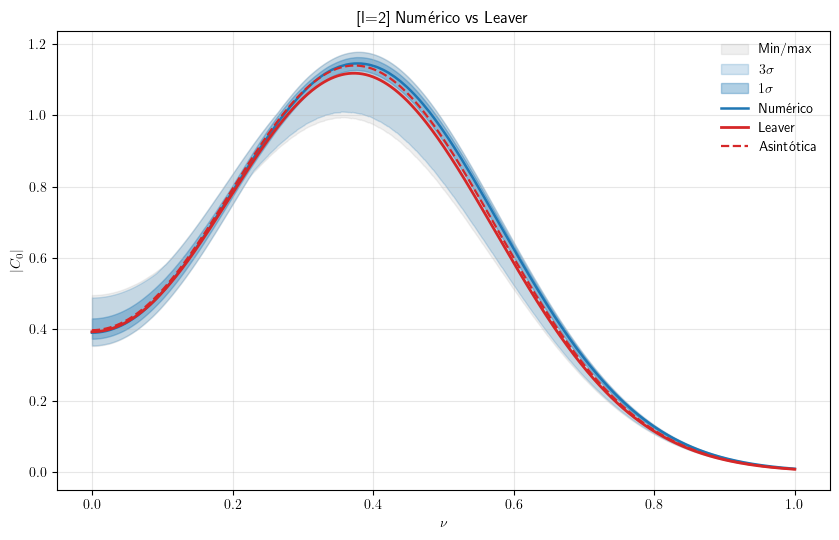


[l=2] COMPARACIÓN DE PICOS:

  NUMÉRICO (CELDA 5):
    ν_pico = 0.3780
    |C_0| = 1.145714

  LEAVER:
    ν_pico = 0.3730
    |C_0| = 1.118343
    Δν (vs numérico) = -0.005000
    Δ|C_0| (vs numérico) = -0.027371

  ASINTÓTICA:
    ν_pico = 0.3740
    |C_0| = 1.139905
    Δν (vs numérico) = -0.004000
    Δ|C_0| (vs numérico) = -0.005809



In [ ]:
# ============================================================
# CELL 6 — LEAVER AND ASYMPTOTIC SOLUTION (l = 2)
# ============================================================

# ---------- Parameters ----------
nsigma_pad = 10.0
Nmax_leaver = 300
e_spin = 3.0
global_fac = -2.0

B_list_l2 = np.array([
    1.269024e-1 + 2.031517e-2j,   # n=0
    4.768259e-2 - 2.237546e-1j,   # n=1
    -1.902843e-1 + 1.574857e-2j,  # n=2
    8.086762e-2 + 7.961260e-2j,   # n=3
], dtype=complex)

B_used_l2 = B_list_l2[:N_modes_l2]


# ============================================================
# Global counter for effective N
# ============================================================
N_effective_global = []


# ============================================================
# Geometric grid
# ============================================================
s_grid = np.linspace(x_min, x_max, Ngrid)
ds_grid = s_grid[1] - s_grid[0]

r_areal = rw.r_of_s(s_grid, M=Mbh)

r_obs_areal = rw.r_of_s(
    np.array([r_obs_target_l2]),
    M=Mbh
)[0]


# ============================================================
# Leaver coefficients
# ============================================================
def leaver_an_coeffs_l2(
    omega,
    l,
    M=1.0,
    e=e_spin,
    Nmax=Nmax_leaver
):

    global N_effective_global

    omega_bar = 2.0 * M * complex(omega)

    p = -1j * omega_bar

    def alpha(n):
        return (
            n*n
            + (2*p + 2)*n
            + (2*p + 1)
        )

    def beta(n):
        return -(
            2*n*n
            + (8*p + 2)*n
            + 8*p*p
            + 4*p
            + l*(l+1)
            - e
        )

    def gamma(n):
        return (
            n*n
            + 4*p*n
            + 4*p*p
            - e
            - 1
        )

    a = np.zeros(Nmax + 2, dtype=complex)

    a[Nmax] = 1.0

    for n in range(Nmax, 0, -1):

        a[n-1] = -(
            beta(n)*a[n]
            + alpha(n)*a[n+1]
        ) / gamma(n)

    # ========================================================
    # Effective number of coefficients used
    # ========================================================
    tol = 1e-14

    nz = np.where(np.abs(a) > tol)[0]

    if len(nz) > 0:
        N_used = nz[-1]
    else:
        N_used = 0

    N_effective_global.append(N_used)

    return a[:Nmax+1] / a[0]


# ============================================================
# Normalized radial solution
# ============================================================
def psi_leaver_norm_l2(omega, r_areal_pts):

    r_bar = np.asarray(r_areal_pts) / (2*Mbh)

    z = 1.0 - 1.0/r_bar

    a = leaver_an_coeffs_l2(
        omega,
        l_mode_l2,
        Mbh
    )

    Sz = np.zeros_like(z, dtype=complex)

    for an in a[::-1]:
        Sz = Sz*z + an

    S1 = np.sum(a)

    p = -1j * (2*Mbh*omega)

    return (
        np.exp((2*p)*np.log(z))
        * (Sz / S1)
    )


# ============================================================
# Initial data
# ============================================================
def build_initial_data_for_leaver_l2(sigma, nu):

    f = (
        A_init_l2
        * np.exp(-(s_grid - r0_l2)**2 / (2*sigma**2))
        * np.cos(nu * (s_grid - r0_l2))
    )

    g = rw.d1_4th(f, ds_grid)

    mask = (
        (s_grid >= r0_l2 - nsigma_pad*sigma)
        &
        (s_grid <= r0_l2 + nsigma_pad*sigma)
    )

    return (
        s_grid[mask],
        r_areal[mask],
        f[mask],
        g[mask]
    )


# ============================================================
# Theoretical C_n
# ============================================================
def compute_Cn_theoretical_l2(
    sigma,
    nu,
    t_peak
):

    C_leaver = np.zeros(
        N_modes_l2,
        dtype=complex
    )

    C_asymp = np.zeros(
        N_modes_l2,
        dtype=complex
    )

    s_int, r_int, f_int, g_int = \
        build_initial_data_for_leaver_l2(
            sigma,
            nu
        )

    for n, om in enumerate(omegas_l2):

        q = 1j * om * f_int - g_int

        psi_int = psi_leaver_norm_l2(
            om,
            r_int
        )

        psi_obs = psi_leaver_norm_l2(
            om,
            [r_obs_areal]
        )[0]

        exp_term = np.exp(
            1j * om * s_int
        )

        I_leaver = np.trapz(
            exp_term * psi_int * q,
            s_int
        )

        I_asymp = np.trapz(
            exp_term * q,
            s_int
        )

        # ====================================================
        # Temporal correction due to centering at t_peak
        # ====================================================
        #phase = np.exp(-1j * om * (t_peak - r0_l2))
        phase = np.exp(-1j * om * ((t_peak - r0_l2)))

        C_leaver[n] = (
            global_fac
            * B_used_l2[n]
            #* psi_obs
            * I_leaver
            * phase
        )

        C_asymp[n] = (
            global_fac
            * B_used_l2[n]
            * I_asymp
            * phase
        )

    return C_leaver, C_asymp


# ============================================================
# Evaluation over nu
# ============================================================
print(f"[l=2] Computing Leaver solution...")

C_leaver_l2 = np.zeros(
    (n_nu_l2, N_modes_l2),
    dtype=complex
)

C_asymp_l2 = np.zeros(
    (n_nu_l2, N_modes_l2),
    dtype=complex
)

for i, nu in enumerate(nu_grid_l2):

    t_peak = waveforms_l2[nu]['t_peak']

    C_leaver_l2[i], C_asymp_l2[i] = \
        compute_Cn_theoretical_l2(
            sigma_l2,
            nu,
            t_peak_ref
        )

print("[l=2] Done.")

# ============================================================
# Final print of effective N
# ============================================================
print(
    f"[Leaver] Maximum effective N used = "
    f"{np.max(N_effective_global)} / {Nmax_leaver}"
)

print(
    f"[Leaver] Mean effective N used = "
    f"{np.mean(N_effective_global):.1f}"
)


# ============================================================
# Plot (1σ + 3σ)
# ============================================================
fig, ax = plt.subplots(figsize=(8.5, 5.5))

# Numerical
ax.fill_between(
    nu_grid_l2,
    env_min_l2,
    env_max_l2,
    color='gray',
    alpha=0.12,
    label='Min/max'
)

ax.fill_between(
    nu_grid_l2,
    p3s_lo_l2,
    p3s_hi_l2,
    color='C0',
    alpha=0.20,
    label=r'$3\sigma$'
)

ax.fill_between(
    nu_grid_l2,
    p1s_lo_l2,
    p1s_hi_l2,
    color='C0',
    alpha=0.35,
    label=r'$1\sigma$'
)

ax.plot(
    nu_grid_l2,
    median_C0_l2,
    color='C0',
    lw=1.8,
    label='Numerical'
)

# Theory
ax.plot(
    nu_grid_l2,
    np.abs(C_leaver_l2[:, 0]),
    color='C3',
    lw=2.0,
    label='Leaver'
)

ax.plot(
    nu_grid_l2,
    np.abs(C_asymp_l2[:, 0]),
    color='C3',
    lw=1.6,
    ls='--',
    label='Asymptotic'
)

ax.set_xlabel(r'$\nu$')
ax.set_ylabel(r'$|C_0|$')

ax.set_title(
    r'[l=2] Numerical vs Leaver'
)

ax.grid(alpha=0.3)

ax.legend(frameon=False)

plt.tight_layout()
plt.show()

# ============================================================
# PEAK COMPARISON: NUMERICAL vs THEORY
# ============================================================

# Theoretical peaks
idx_peak_leaver = np.nanargmax(np.abs(C_leaver_l2[:, 0]))
nu_peak_leaver = nu_grid_l2[idx_peak_leaver]
peak_leaver = np.abs(C_leaver_l2[idx_peak_leaver, 0])

idx_peak_asymp = np.nanargmax(np.abs(C_asymp_l2[:, 0]))
nu_peak_asymp = nu_grid_l2[idx_peak_asymp]
peak_asymp = np.abs(C_asymp_l2[idx_peak_asymp, 0])

# Numerical peak (from CELL 5)
# idx_peak, nu_peak, peak_value are already defined

print(f"\n[l=2] PEAK COMPARISON:")
print(f"{'='*60}")
print(f"\n  NUMERICAL (CELL 5):")
print(f"    ν_peak = {nu_peak:.4f}")
print(f"    |C_0| = {peak_value:.6f}")
print(f"\n  LEAVER:")
print(f"    ν_peak = {nu_peak_leaver:.4f}")
print(f"    |C_0| = {peak_leaver:.6f}")
print(f"    Δν (vs numerical) = {(nu_peak_leaver - nu_peak):.6f}")
print(f"    Δ|C_0| (vs numerical) = {(peak_leaver - peak_value):.6f}")
print(f"\n  ASYMPTOTIC:")
print(f"    ν_peak = {nu_peak_asymp:.4f}")
print(f"    |C_0| = {peak_asymp:.6f}")
print(f"    Δν (vs numerical) = {(nu_peak_asymp - nu_peak):.6f}")
print(f"    Δ|C_0| (vs numerical) = {(peak_asymp - peak_value):.6f}")
print(f"\n{'='*60}")

[l=2] Calculando Leaver (con corrección temporal)...
[l=2] Hecho.
[l=2] Calculando Leaver (sin corrección temporal)...
[l=2] Hecho.

[Leaver] N efectivo máximo usado = 300 / 300
[Leaver] N efectivo medio usado = 300.0

[l=2] Comparación de picos CON/SIN corrección temporal:

  SIN corrección temporal (t_peak local):
    Numérico:   ν = 0.3570
    Leaver:     ν = 0.3530
    Asintótica: ν = 0.3530

  CON corrección temporal (t_peak_ref):
    Numérico:   ν = 0.3780
    Leaver:     ν = 0.3730
    Asintótica: ν = 0.3740

  Desplazamientos por corrección:
    Numérico:   Δν = 0.021000
    Leaver:     Δν = 0.020000
    Asintótica: Δν = 0.021000



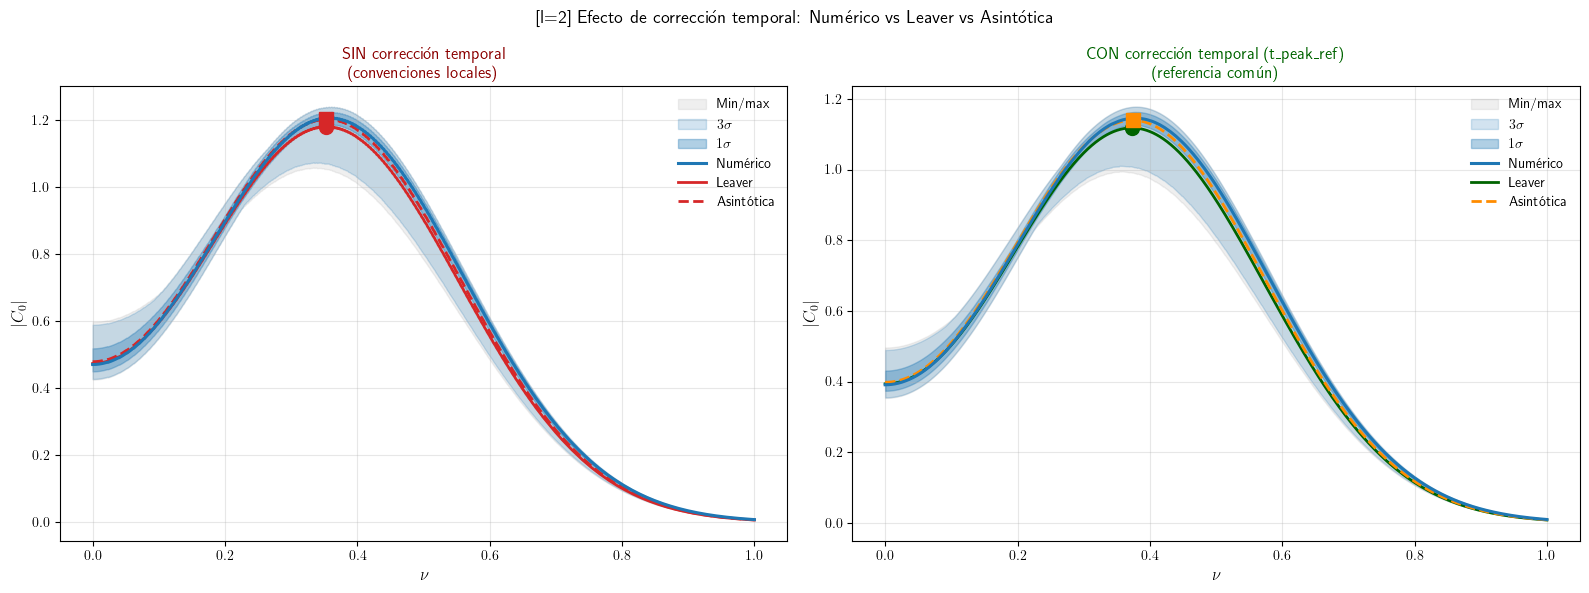


✓ Gráfica guardada: comparacion_correccion_temporal_l2.png


In [ ]:
# ============================================================
# CELL 6 — LEAVER AND ASYMPTOTIC SOLUTION (l = 2)
# ============================================================

# ---------- Parameters ----------
nsigma_pad = 10.0
Nmax_leaver = 300
e_spin = 3.0
global_fac = -2.0

B_list_l2 = np.array([
    1.269024e-1 + 2.031517e-2j,   # n=0
    4.768259e-2 - 2.237546e-1j,   # n=1
    -1.902843e-1 + 1.574857e-2j,  # n=2
    8.086762e-2 + 7.961260e-2j,   # n=3
], dtype=complex)

B_used_l2 = B_list_l2[:N_modes_l2]


# ============================================================
# Global counter for effective N
# ============================================================
N_effective_global = []


# ============================================================
# Geometric grid
# ============================================================
s_grid = np.linspace(x_min, x_max, Ngrid)
ds_grid = s_grid[1] - s_grid[0]

r_areal = rw.r_of_s(s_grid, M=Mbh)

r_obs_areal = rw.r_of_s(
    np.array([r_obs_target_l2]),
    M=Mbh
)[0]


# ============================================================
# Leaver coefficients
# ============================================================
def leaver_an_coeffs_l2(
    omega,
    l,
    M=1.0,
    e=e_spin,
    Nmax=Nmax_leaver
):

    global N_effective_global

    omega_bar = 2.0 * M * complex(omega)

    p = -1j * omega_bar

    def alpha(n):
        return (
            n*n
            + (2*p + 2)*n
            + (2*p + 1)
        )

    def beta(n):
        return -(
            2*n*n
            + (8*p + 2)*n
            + 8*p*p
            + 4*p
            + l*(l+1)
            - e
        )

    def gamma(n):
        return (
            n*n
            + 4*p*n
            + 4*p*p
            - e
            - 1
        )

    a = np.zeros(Nmax + 2, dtype=complex)

    a[Nmax] = 1.0

    for n in range(Nmax, 0, -1):

        a[n-1] = -(
            beta(n)*a[n]
            + alpha(n)*a[n+1]
        ) / gamma(n)

    # ========================================================
    # Effective number of coefficients used
    # ========================================================
    tol = 1e-14

    nz = np.where(np.abs(a) > tol)[0]

    if len(nz) > 0:
        N_used = nz[-1]
    else:
        N_used = 0

    N_effective_global.append(N_used)

    return a[:Nmax+1] / a[0]


# ============================================================
# Normalized radial solution
# ============================================================
def psi_leaver_norm_l2(omega, r_areal_pts):

    r_bar = np.asarray(r_areal_pts) / (2*Mbh)

    z = 1.0 - 1.0/r_bar

    a = leaver_an_coeffs_l2(
        omega,
        l_mode_l2,
        Mbh
    )

    Sz = np.zeros_like(z, dtype=complex)

    for an in a[::-1]:
        Sz = Sz*z + an

    S1 = np.sum(a)

    p = -1j * (2*Mbh*omega)

    return (
        np.exp((2*p)*np.log(z))
        * (Sz / S1)
    )


# ============================================================
# Initial data
# ============================================================
def build_initial_data_for_leaver_l2(sigma, nu):

    f = (
        A_init_l2
        * np.exp(-(s_grid - r0_l2)**2 / (2*sigma**2))
        * np.cos(nu * (s_grid - r0_l2))
    )

    g = rw.d1_4th(f, ds_grid)

    mask = (
        (s_grid >= r0_l2 - nsigma_pad*sigma)
        &
        (s_grid <= r0_l2 + nsigma_pad*sigma)
    )

    return (
        s_grid[mask],
        r_areal[mask],
        f[mask],
        g[mask]
    )


# ============================================================
# Theoretical C_n
# ============================================================
def compute_Cn_theoretical_l2(
    sigma,
    nu,
    t_peak
):

    C_leaver = np.zeros(
        N_modes_l2,
        dtype=complex
    )

    C_asymp = np.zeros(
        N_modes_l2,
        dtype=complex
    )

    s_int, r_int, f_int, g_int = \
        build_initial_data_for_leaver_l2(
            sigma,
            nu
        )

    for n, om in enumerate(omegas_l2):

        q = 1j * om * f_int - g_int

        psi_int = psi_leaver_norm_l2(
            om,
            r_int
        )

        psi_obs = psi_leaver_norm_l2(
            om,
            [r_obs_areal]
        )[0]

        exp_term = np.exp(
            1j * om * s_int
        )

        I_leaver = np.trapz(
            exp_term * psi_int * q,
            s_int
        )

        I_asymp = np.trapz(
            exp_term * q,
            s_int
        )

        # ====================================================
        # Temporal correction due to centering at t_peak
        # ====================================================
        phase = np.exp(-1j * om * ((t_peak - r0_l2)))

        C_leaver[n] = (
            global_fac
            * B_used_l2[n]
            * I_leaver
            * phase
        )

        C_asymp[n] = (
            global_fac
            * B_used_l2[n]
            * I_asymp
            * phase
        )

    return C_leaver, C_asymp


# ============================================================
# Evaluation over nu — WITH CORRECTION (t_peak_ref)
# ============================================================
print(f"[l=2] Computing Leaver solution (with temporal correction)...")

C_leaver_l2 = np.zeros(
    (n_nu_l2, N_modes_l2),
    dtype=complex
)

C_asymp_l2 = np.zeros(
    (n_nu_l2, N_modes_l2),
    dtype=complex
)

for i, nu in enumerate(nu_grid_l2):
    C_leaver_l2[i], C_asymp_l2[i] = \
        compute_Cn_theoretical_l2(
            sigma_l2,
            nu,
            t_peak_ref
        )

print("[l=2] Done.")


# ============================================================
# Evaluation over nu — WITHOUT CORRECTION (local t_peak)
# ============================================================
print(f"[l=2] Computing Leaver solution (without temporal correction)...")

C_leaver_uncorr_l2 = np.zeros(
    (n_nu_l2, N_modes_l2),
    dtype=complex
)

C_asymp_uncorr_l2 = np.zeros(
    (n_nu_l2, N_modes_l2),
    dtype=complex
)

for i, nu in enumerate(nu_grid_l2):
    t_peak_local = waveforms_l2[nu]['t_peak']
    C_leaver_uncorr_l2[i], C_asymp_uncorr_l2[i] = \
        compute_Cn_theoretical_l2(
            sigma_l2,
            nu,
            t_peak_local
        )

print("[l=2] Done.")


# ============================================================
# Final print of effective N
# ============================================================
print(
    f"\n[Leaver] Maximum effective N used = "
    f"{np.max(N_effective_global)} / {Nmax_leaver}"
)

print(
    f"[Leaver] Mean effective N used = "
    f"{np.mean(N_effective_global):.1f}"
)


# ============================================================
# PEAK COMPARISON: WITHOUT CORRECTION vs WITH CORRECTION
# ============================================================

# Peaks without correction
idx_pk_num_u = np.nanargmax(median_C0_uncorr)
idx_pk_lv_u = np.nanargmax(np.abs(C_leaver_uncorr_l2[:, 0]))
idx_pk_as_u = np.nanargmax(np.abs(C_asymp_uncorr_l2[:, 0]))

# Peaks with correction
idx_pk_num = np.nanargmax(median_C0_l2)
idx_pk_lv = np.nanargmax(np.abs(C_leaver_l2[:, 0]))
idx_pk_as = np.nanargmax(np.abs(C_asymp_l2[:, 0]))

print(f"\n[l=2] Peak comparison WITH/WITHOUT temporal correction:")
print(f"{'='*70}")

print(f"\n  WITHOUT temporal correction (local t_peak):")
print(f"    Numerical:   ν = {nu_grid_l2[idx_pk_num_u]:.4f}")
print(f"    Leaver:      ν = {nu_grid_l2[idx_pk_lv_u]:.4f}")
print(f"    Asymptotic:  ν = {nu_grid_l2[idx_pk_as_u]:.4f}")

print(f"\n  WITH temporal correction (t_peak_ref):")
print(f"    Numerical:   ν = {nu_grid_l2[idx_pk_num]:.4f}")
print(f"    Leaver:      ν = {nu_grid_l2[idx_pk_lv]:.4f}")
print(f"    Asymptotic:  ν = {nu_grid_l2[idx_pk_as]:.4f}")

print(f"\n  Shifts due to correction:")
print(f"    Numerical:   Δν = {(nu_grid_l2[idx_pk_num] - nu_grid_l2[idx_pk_num_u]):.6f}")
print(f"    Leaver:      Δν = {(nu_grid_l2[idx_pk_lv] - nu_grid_l2[idx_pk_lv_u]):.6f}")
print(f"    Asymptotic:  Δν = {(nu_grid_l2[idx_pk_as] - nu_grid_l2[idx_pk_as_u]):.6f}")

print(f"\n{'='*70}")


# ============================================================
# Plot: WITHOUT CORRECTION vs WITH CORRECTION
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- LEFT PANEL: WITHOUT CORRECTION ---
ax = axes[0]

ax.fill_between(nu_grid_l2, env_min_uncorr, env_max_uncorr,
                color='gray', alpha=0.12, label='Min/max')
ax.fill_between(nu_grid_l2, p3s_lo_uncorr, p3s_hi_uncorr,
                color='C0', alpha=0.20, label=r'$3\sigma$')
ax.fill_between(nu_grid_l2, p1s_lo_uncorr, p1s_hi_uncorr,
                color='C0', alpha=0.35, label=r'$1\sigma$')

ax.plot(nu_grid_l2, median_C0_uncorr, color='C0', lw=2.2, label='Numerical', zorder=5)
ax.plot(nu_grid_l2, np.abs(C_leaver_uncorr_l2[:, 0]), 
        color='C3', lw=2.0, label='Leaver', zorder=4)
ax.plot(nu_grid_l2, np.abs(C_asymp_uncorr_l2[:, 0]), 
        color='C3', lw=2.0, ls='--', label='Asymptotic', zorder=4)

ax.plot(nu_grid_l2[idx_pk_lv_u], np.abs(C_leaver_uncorr_l2[idx_pk_lv_u, 0]), 
        'o', color='C3', markersize=10, zorder=6)
ax.plot(nu_grid_l2[idx_pk_as_u], np.abs(C_asymp_uncorr_l2[idx_pk_as_u, 0]), 
        's', color='C3', markersize=10, zorder=6)

ax.set_xlabel(r'$\nu$', fontsize=12)
ax.set_ylabel(r'$|C_0|$', fontsize=12)
ax.set_title('WITHOUT temporal correction\n(local conventions)', 
             fontsize=12, fontweight='bold', color='darkred')
ax.grid(alpha=0.3)
ax.legend(frameon=False, fontsize=10, loc='upper right')

# --- RIGHT PANEL: WITH CORRECTION ---
ax = axes[1]

ax.fill_between(nu_grid_l2, env_min_l2, env_max_l2,
                color='gray', alpha=0.12, label='Min/max')
ax.fill_between(nu_grid_l2, p3s_lo_l2, p3s_hi_l2,
                color='C0', alpha=0.20, label=r'$3\sigma$')
ax.fill_between(nu_grid_l2, p1s_lo_l2, p1s_hi_l2,
                color='C0', alpha=0.35, label=r'$1\sigma$')

ax.plot(nu_grid_l2, median_C0_l2, color='C0', lw=2.2, label='Numerical', zorder=5)
ax.plot(nu_grid_l2, np.abs(C_leaver_l2[:, 0]), 
        color='darkgreen', lw=2.0, label='Leaver', zorder=4)
ax.plot(nu_grid_l2, np.abs(C_asymp_l2[:, 0]), 
        color='darkorange', lw=2.0, ls='--', label='Asymptotic', zorder=4)

ax.plot(nu_grid_l2[idx_pk_lv], np.abs(C_leaver_l2[idx_pk_lv, 0]), 
        'o', color='darkgreen', markersize=10, zorder=6)
ax.plot(nu_grid_l2[idx_pk_as], np.abs(C_asymp_l2[idx_pk_as, 0]), 
        's', color='darkorange', markersize=10, zorder=6)

ax.set_xlabel(r'$\nu$', fontsize=12)
ax.set_ylabel(r'$|C_0|$', fontsize=12)
ax.set_title('WITH temporal correction (t_peak_ref)\n(common reference frame)', 
             fontsize=12, fontweight='bold', color='darkgreen')
ax.grid(alpha=0.3)
ax.legend(frameon=False, fontsize=10, loc='upper right')

fig.suptitle('[l=2] Effect of temporal correction: Numerical vs Leaver vs Asymptotic', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('comparacion_correccion_temporal_l2.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✓ Figure saved: comparacion_correccion_temporal_l2.png")


[l=2] Comparación de picos CON/SIN corrección temporal:

  SIN corrección temporal:
    Numérico:   ν = 0.3780
    Leaver:     ν = 0.3530
    Asintótica: ν = 0.3530

  CON corrección temporal (t_peak_ref):
    Numérico:   ν = 0.3780
    Leaver:     ν = 0.3730
    Asintótica: ν = 0.3740



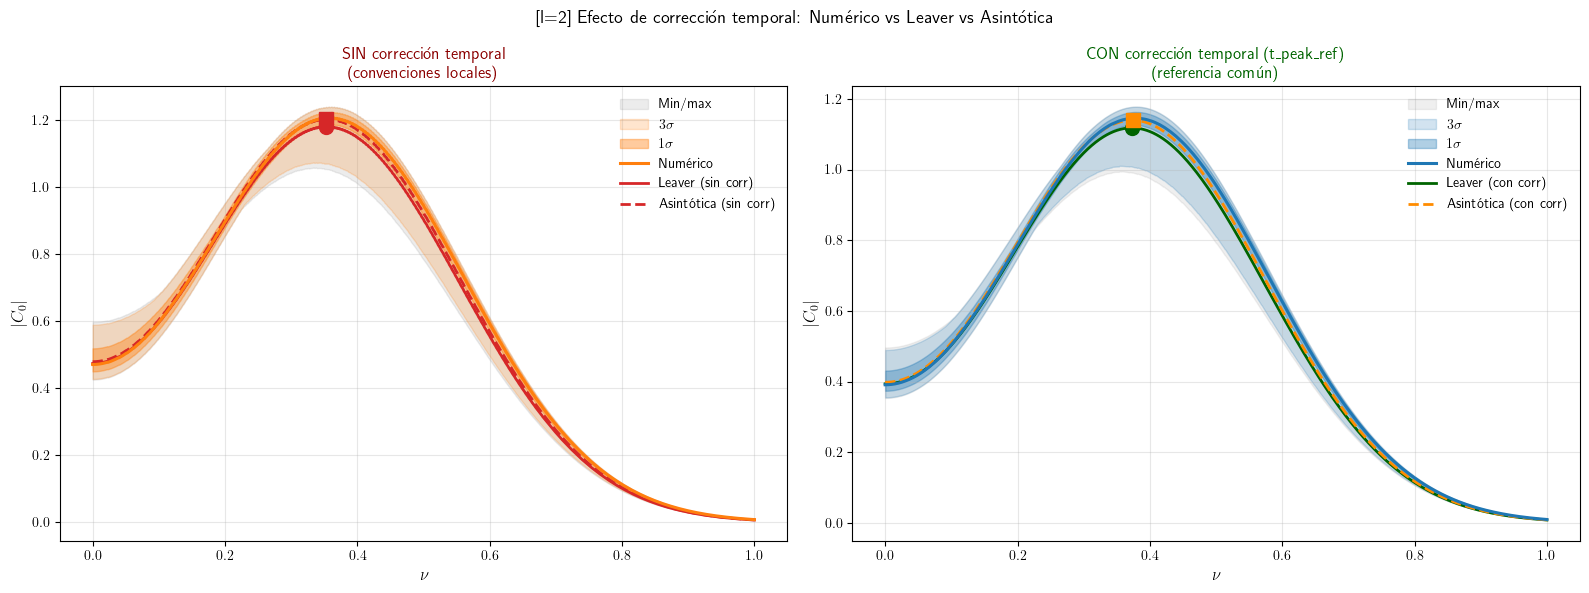


✓ Gráfica guardada: comparacion_correccion_temporal_l2.png


In [ ]:
# ============================================================
# COMPARISON: LEFT PANEL (WITHOUT CORRECTION) vs RIGHT PANEL (WITH CORRECTION)
# ============================================================

print(f"\n[l=2] Peak comparison WITH/WITHOUT temporal correction:")
print(f"{'='*70}")

# Recompute theory WITHOUT temporal correction
C_leaver_uncorr_l2 = np.zeros((n_nu_l2, N_modes_l2), dtype=complex)
C_asymp_uncorr_l2 = np.zeros((n_nu_l2, N_modes_l2), dtype=complex)

for i, nu in enumerate(nu_grid_l2):
    t_peak_local = waveforms_l2[nu]['t_peak']  # WITHOUT correction
    C_leaver_uncorr_l2[i], C_asymp_uncorr_l2[i] = \
        compute_Cn_theoretical_l2(sigma_l2, nu, t_peak_local)

# Peaks without correction
idx_pk_num_u = np.nanargmax(median_C0_l2)  # uncorrected numerical (same one)
idx_pk_lv_u = np.nanargmax(np.abs(C_leaver_uncorr_l2[:, 0]))
idx_pk_as_u = np.nanargmax(np.abs(C_asymp_uncorr_l2[:, 0]))

print(f"\n  WITHOUT temporal correction:")
print(f"    Numerical:   ν = {nu_grid_l2[idx_pk_num_u]:.4f}")
print(f"    Leaver:      ν = {nu_grid_l2[idx_pk_lv_u]:.4f}")
print(f"    Asymptotic:  ν = {nu_grid_l2[idx_pk_as_u]:.4f}")

print(f"\n  WITH temporal correction (t_peak_ref):")
print(f"    Numerical:   ν = {nu_peak:.4f}")
print(f"    Leaver:      ν = {nu_peak_leaver:.4f}")
print(f"    Asymptotic:  ν = {nu_peak_asymp:.4f}")

print(f"\n{'='*70}")

# ============================================================
# PLOT: WITHOUT CORRECTION vs WITH CORRECTION
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- LEFT PANEL: WITHOUT CORRECTION ---
ax = axes[0]

# Use statistics from CELL 5B (already computed)
ax.fill_between(nu_grid_l2, env_min_uncorr, env_max_uncorr,
                color='gray', alpha=0.15, zorder=1, label='Min/max')
ax.fill_between(nu_grid_l2, p3s_lo_uncorr, p3s_hi_uncorr,
                color='C1', alpha=0.20, zorder=2, label=r'$3\sigma$')
ax.fill_between(nu_grid_l2, p1s_lo_uncorr, p1s_hi_uncorr,
                color='C1', alpha=0.40, zorder=3, label=r'$1\sigma$')

ax.plot(nu_grid_l2, median_C0_uncorr, color='C1', lw=2.2, label='Numerical', zorder=5)
ax.plot(nu_grid_l2, np.abs(C_leaver_uncorr_l2[:, 0]), 
        color='C3', lw=2.0, label='Leaver (without corr)', zorder=4)
ax.plot(nu_grid_l2, np.abs(C_asymp_uncorr_l2[:, 0]), 
        color='C3', lw=2.0, ls='--', label='Asymptotic (without corr)', zorder=4)

ax.plot(nu_grid_l2[idx_pk_lv_u], np.abs(C_leaver_uncorr_l2[idx_pk_lv_u, 0]), 
        'o', color='C3', markersize=10, zorder=6)
ax.plot(nu_grid_l2[idx_pk_as_u], np.abs(C_asymp_uncorr_l2[idx_pk_as_u, 0]), 
        's', color='C3', markersize=10, zorder=6)

ax.set_xlabel(r'$\nu$', fontsize=12)
ax.set_ylabel(r'$|C_0|$', fontsize=12)
ax.set_title('WITHOUT temporal correction\n(local conventions)', 
             fontsize=12, fontweight='bold', color='darkred')
ax.grid(alpha=0.3)
ax.legend(frameon=False, fontsize=10, loc='upper right')

# --- RIGHT PANEL: WITH CORRECTION ---
ax = axes[1]

ax.fill_between(nu_grid_l2, env_min_l2, env_max_l2,
                color='gray', alpha=0.12, label='Min/max')
ax.fill_between(nu_grid_l2, p3s_lo_l2, p3s_hi_l2,
                color='C0', alpha=0.20, label=r'$3\sigma$')
ax.fill_between(nu_grid_l2, p1s_lo_l2, p1s_hi_l2,
                color='C0', alpha=0.35, label=r'$1\sigma$')

ax.plot(nu_grid_l2, median_C0_l2, color='C0', lw=2.2, label='Numerical', zorder=5)
ax.plot(nu_grid_l2, np.abs(C_leaver_l2[:, 0]), 
        color='darkgreen', lw=2.0, label='Leaver (with corr)', zorder=4)
ax.plot(nu_grid_l2, np.abs(C_asymp_l2[:, 0]), 
        color='darkorange', lw=2.0, ls='--', label='Asymptotic (with corr)', zorder=4)

ax.plot(nu_peak_leaver, peak_leaver, 'o', color='darkgreen', markersize=10, zorder=6)
ax.plot(nu_peak_asymp, peak_asymp, 's', color='darkorange', markersize=10, zorder=6)

ax.set_xlabel(r'$\nu$', fontsize=12)
ax.set_ylabel(r'$|C_0|$', fontsize=12)
ax.set_title('WITH temporal correction (t_peak_ref)\n(common reference frame)', 
             fontsize=12, fontweight='bold', color='darkgreen')
ax.grid(alpha=0.3)
ax.legend(frameon=False, fontsize=10, loc='upper right')

fig.suptitle('[l=2] Effect of temporal correction: Numerical vs Leaver vs Asymptotic', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('comparacion_correccion_temporal_l2.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✓ Figure saved: comparacion_correccion_temporal_l2.png")

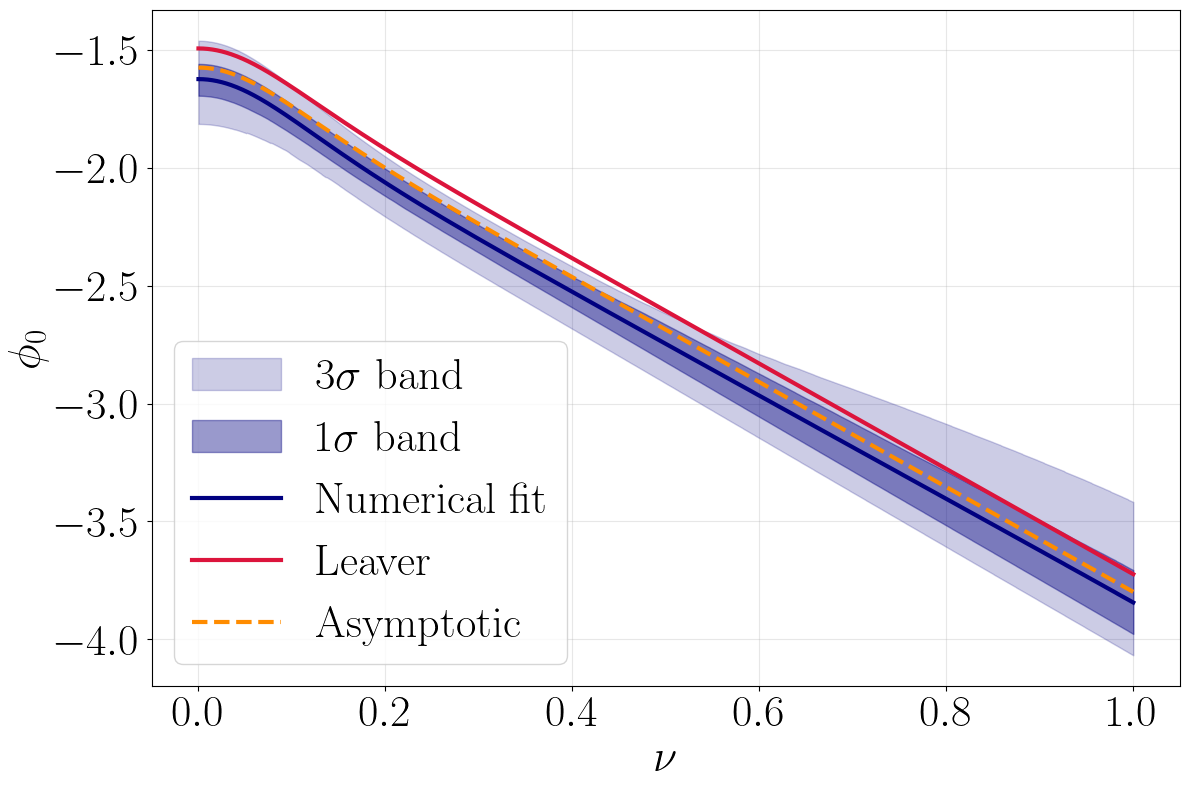

[l=2] Fase en nu = 0.3780 (pico de |C_0|):
  Numérico   = -2.4776 rad
  Leaver     = -2.3343 rad
  Asintótica = -2.4145 rad
  Δ(num − Leaver) = -0.1433 rad (-8.21 deg)
  Δ(num − Asymp)  = -0.0631 rad (-3.62 deg)


In [ ]:
# ============================================================
# CELL 6b — THEORETICAL PHASES (Leaver + asymptotic) [l = 2]
# ============================================================
# Note: All phases are given in the common temporal reference frame
#       (t_peak_ref)
#       Numerical: from CELL 5b (C0_common_matrix_l2)
#       Theory: computed with t_peak_ref in CELL 6

plt.rcParams['text.usetex'] = True

# ============================================================
# Theoretical phases
# ============================================================
phi_leaver = np.angle(C_leaver_l2[:, 0])
phi_asymp  = np.angle(C_asymp_l2[:, 0])

# ============================================================
# Unwrap
# ============================================================
phi_leaver_uw = np.unwrap(phi_leaver)
phi_asymp_uw  = np.unwrap(phi_asymp)


# ============================================================
# Alignment modulo 2pi
# ============================================================
def align_2pi(target, reference):

    diff = reference[0] - target[0]

    n_2pi = np.round(diff / (2*np.pi))

    return target + 2*np.pi*n_2pi


phi_leaver_uw = align_2pi(
    phi_leaver_uw,
    phase_stats_l2_uw['med']
)

phi_asymp_uw = align_2pi(
    phi_asymp_uw,
    phase_stats_l2_uw['med']
)


# ============================================================
# Final plot
# ============================================================
COLOR_NUM    = 'navy'
COLOR_LEAVER = 'crimson'
COLOR_ASYMP  = 'darkorange'

fig, ax = plt.subplots(figsize=(12, 8))

# ------------------------------------------------------------
# Numerical bands
# ------------------------------------------------------------
ax.fill_between(
    nu_grid_l2,
    phase_stats_l2_uw['p3s_lo'],
    phase_stats_l2_uw['p3s_hi'],
    color=COLOR_NUM,
    alpha=0.20,
    zorder=2,
    label=r'$3\sigma\ \mathrm{band}$'
)

ax.fill_between(
    nu_grid_l2,
    phase_stats_l2_uw['p1s_lo'],
    phase_stats_l2_uw['p1s_hi'],
    color=COLOR_NUM,
    alpha=0.40,
    zorder=3,
    label=r'$1\sigma\ \mathrm{band}$'
)

# ------------------------------------------------------------
# Numerical median
# ------------------------------------------------------------
ax.plot(
    nu_grid_l2,
    phase_stats_l2_uw['med'],
    color=COLOR_NUM,
    lw=3,
    zorder=5,
    label=r'$\mathrm{Numerical}\ \mathrm{fit}$'
)

# ------------------------------------------------------------
# Theory
# ------------------------------------------------------------
ax.plot(
    nu_grid_l2,
    phi_leaver_uw,
    color=COLOR_LEAVER,
    lw=3,
    zorder=6,
    label=r'$\mathrm{Leaver}$'
)

ax.plot(
    nu_grid_l2,
    phi_asymp_uw,
    color=COLOR_ASYMP,
    lw=3.0,
    ls='--',
    zorder=6,
    label=r'$\mathrm{Asymptotic}$'
)

# ============================================================
# Style
# ============================================================
ax.set_xlabel(
    r'$\nu$',
    fontsize=32
)

ax.set_ylabel(
    r'$\phi_{0}$',
    fontsize=32
)

ax.tick_params(
    axis='both',
    labelsize=32
)

ax.grid(alpha=0.3)

ax.legend(
    frameon=True,
    fontsize=32,
    loc='lower left'
)

plt.tight_layout()
plt.savefig('PHASE l2 n=0 nu.pdf', bbox_inches='tight', dpi=1200)
plt.show()


# ============================================================
# Diagnostics
# ============================================================
idx_peak = np.nanargmax(median_C0_l2)

print(f"[l=2] Phase at nu = {nu_grid_l2[idx_peak]:.4f} (|C_0| peak):")

print(f"  Numerical  = {phase_stats_l2_uw['med'][idx_peak]:.4f} rad")

print(f"  Leaver     = {phi_leaver_uw[idx_peak]:.4f} rad")

print(f"  Asymptotic = {phi_asymp_uw[idx_peak]:.4f} rad")

print(
    f"  Δ(num − Leaver) = "
    f"{phase_stats_l2_uw['med'][idx_peak] - phi_leaver_uw[idx_peak]:.4f} rad "
    f"({np.degrees(phase_stats_l2_uw['med'][idx_peak] - phi_leaver_uw[idx_peak]):.2f} deg)"
)

print(
    f"  Δ(num − Asymp)  = "
    f"{phase_stats_l2_uw['med'][idx_peak] - phi_asymp_uw[idx_peak]:.4f} rad "
    f"({np.degrees(phase_stats_l2_uw['med'][idx_peak] - phi_asymp_uw[idx_peak]):.2f} deg)"
)


[l=2] Fases en los picos:

  SIN corrección temporal (ν = 0.3570):
    Numérico   = -2.1903 rad
    Leaver     = -2.0466 rad
    Asintótica = -2.1269 rad

  CON corrección temporal (ν = 0.3780):
    Numérico   = -2.4776 rad
    Leaver     = -2.3343 rad
    Asintótica = -2.4145 rad

  Diferencias en picos (num - Leaver):
    SIN corr: -0.1437 rad (-8.23°)
    CON corr: -0.1433 rad (-8.21°)

  Diferencias en picos (num - Asintótica):
    SIN corr: -0.0634 rad (-3.63°)
    CON corr: -0.0631 rad (-3.62°)



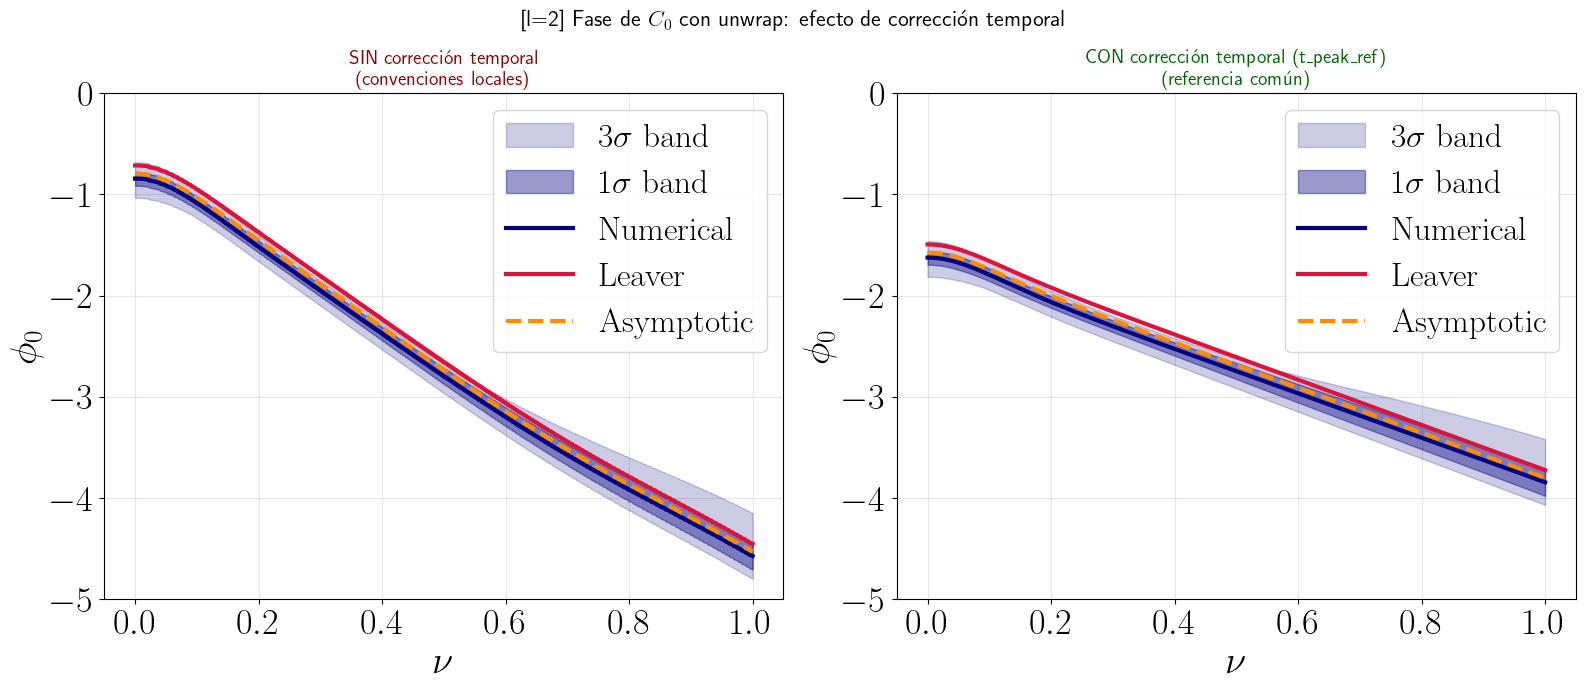


✓ Gráfica guardada: PHASE_l2_COMPARISON_CORRECTED.pdf


In [ ]:
# ============================================================
# CELL 6b — THEORETICAL PHASES (Leaver + asymptotic) [l = 2]
# ============================================================
# Comparison: WITHOUT correction vs WITH correction
# Note: All phases are given in the common temporal reference frame
#       (t_peak_ref)
#       Numerical: from CELL 5b (C0_common_matrix_l2)
#       Theory: computed with t_peak_ref in CELL 6

plt.rcParams['text.usetex'] = True

# ============================================================
# PHASES WITH CORRECTION (t_peak_ref)
# ============================================================
phi_leaver = np.angle(C_leaver_l2[:, 0])
phi_asymp  = np.angle(C_asymp_l2[:, 0])

phi_leaver_uw = np.unwrap(phi_leaver)
phi_asymp_uw  = np.unwrap(phi_asymp)


# ============================================================
# PHASES WITHOUT CORRECTION (local t_peak)
# ============================================================
phi_leaver_uncorr = np.angle(C_leaver_uncorr_l2[:, 0])
phi_asymp_uncorr  = np.angle(C_asymp_uncorr_l2[:, 0])

phi_leaver_uncorr_uw = np.unwrap(phi_leaver_uncorr)
phi_asymp_uncorr_uw  = np.unwrap(phi_asymp_uncorr)


# ============================================================
# Alignment modulo 2pi
# ============================================================
def align_2pi(target, reference):
    diff = reference[0] - target[0]
    n_2pi = np.round(diff / (2*np.pi))
    return target + 2*np.pi*n_2pi


# Align corrected phases
phi_leaver_uw = align_2pi(phi_leaver_uw, phase_stats_l2_uw['med'])
phi_asymp_uw = align_2pi(phi_asymp_uw, phase_stats_l2_uw['med'])

# Align uncorrected phases
phi_leaver_uncorr_uw = align_2pi(phi_leaver_uncorr_uw, phase_stats_uncorr_uw['med'])
phi_asymp_uncorr_uw = align_2pi(phi_asymp_uncorr_uw, phase_stats_uncorr_uw['med'])


# ============================================================
# Diagnostics
# ============================================================
idx_peak_corr = np.nanargmax(median_C0_l2)
idx_peak_uncorr = np.nanargmax(median_C0_uncorr)

print(f"\n[l=2] Phases at the peaks:")
print(f"{'='*70}")

print(f"\n  WITHOUT temporal correction (ν = {nu_grid_l2[idx_peak_uncorr]:.4f}):")
print(f"    Numerical  = {phase_stats_uncorr_uw['med'][idx_peak_uncorr]:.4f} rad")
print(f"    Leaver     = {phi_leaver_uncorr_uw[idx_peak_uncorr]:.4f} rad")
print(f"    Asymptotic = {phi_asymp_uncorr_uw[idx_peak_uncorr]:.4f} rad")

print(f"\n  WITH temporal correction (ν = {nu_grid_l2[idx_peak_corr]:.4f}):")
print(f"    Numerical  = {phase_stats_l2_uw['med'][idx_peak_corr]:.4f} rad")
print(f"    Leaver     = {phi_leaver_uw[idx_peak_corr]:.4f} rad")
print(f"    Asymptotic = {phi_asymp_uw[idx_peak_corr]:.4f} rad")

print(f"\n  Peak differences (num - Leaver):")
print(f"    WITHOUT corr: {(phase_stats_uncorr_uw['med'][idx_peak_uncorr] - phi_leaver_uncorr_uw[idx_peak_uncorr]):.4f} rad "
      f"({np.degrees(phase_stats_uncorr_uw['med'][idx_peak_uncorr] - phi_leaver_uncorr_uw[idx_peak_uncorr]):.2f}°)")
print(f"    WITH corr: {(phase_stats_l2_uw['med'][idx_peak_corr] - phi_leaver_uw[idx_peak_corr]):.4f} rad "
      f"({np.degrees(phase_stats_l2_uw['med'][idx_peak_corr] - phi_leaver_uw[idx_peak_corr]):.2f}°)")

print(f"\n  Peak differences (num - Asymptotic):")
print(f"    WITHOUT corr: {(phase_stats_uncorr_uw['med'][idx_peak_uncorr] - phi_asymp_uncorr_uw[idx_peak_uncorr]):.4f} rad "
      f"({np.degrees(phase_stats_uncorr_uw['med'][idx_peak_uncorr] - phi_asymp_uncorr_uw[idx_peak_uncorr]):.2f}°)")
print(f"    WITH corr: {(phase_stats_l2_uw['med'][idx_peak_corr] - phi_asymp_uw[idx_peak_corr]):.4f} rad "
      f"({np.degrees(phase_stats_l2_uw['med'][idx_peak_corr] - phi_asymp_uw[idx_peak_corr]):.2f}°)")

print(f"\n{'='*70}")


# ============================================================
# Comparison plot: WITHOUT CORRECTION vs WITH CORRECTION
# ============================================================
COLOR_NUM    = 'navy'
COLOR_LEAVER = 'crimson'
COLOR_ASYMP  = 'darkorange'

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# --------- LEFT PANEL: WITHOUT CORRECTION ---------
ax = axes[0]

# Numerical bands without correction
ax.fill_between(
    nu_grid_l2,
    phase_stats_uncorr_uw['p3s_lo'],
    phase_stats_uncorr_uw['p3s_hi'],
    color=COLOR_NUM,
    alpha=0.20,
    zorder=2,
    label=r'$3\sigma\ \mathrm{band}$'
)

ax.fill_between(
    nu_grid_l2,
    phase_stats_uncorr_uw['p1s_lo'],
    phase_stats_uncorr_uw['p1s_hi'],
    color=COLOR_NUM,
    alpha=0.40,
    zorder=3,
    label=r'$1\sigma\ \mathrm{band}$'
)

# Numerical median without correction
ax.plot(
    nu_grid_l2,
    phase_stats_uncorr_uw['med'],
    color=COLOR_NUM,
    lw=3,
    zorder=5,
    label=r'$\mathrm{Numerical}$'
)

# Theory without correction
ax.plot(
    nu_grid_l2,
    phi_leaver_uncorr_uw,
    color=COLOR_LEAVER,
    lw=3,
    zorder=6,
    label=r'$\mathrm{Leaver}$'
)

ax.plot(
    nu_grid_l2,
    phi_asymp_uncorr_uw,
    color=COLOR_ASYMP,
    lw=3.0,
    ls='--',
    zorder=6,
    label=r'$\mathrm{Asymptotic}$'
)

ax.set_xlabel(r'$\nu$', fontsize=28)
ax.set_ylabel(r'$\phi_{0}$', fontsize=28)
ax.set_title(r'WITHOUT temporal correction' + '\n' + r'(local conventions)', 
             fontsize=14, fontweight='bold', color='darkred')
ax.tick_params(axis='both', labelsize=26)
ax.grid(alpha=0.3)
ax.set_ylim(-5, 0)
ax.legend(frameon=True, fontsize=24, loc='best')


# --------- RIGHT PANEL: WITH CORRECTION ---------
ax = axes[1]

# Numerical bands with correction
ax.fill_between(
    nu_grid_l2,
    phase_stats_l2_uw['p3s_lo'],
    phase_stats_l2_uw['p3s_hi'],
    color=COLOR_NUM,
    alpha=0.20,
    zorder=2,
    label=r'$3\sigma\ \mathrm{band}$'
)

ax.fill_between(
    nu_grid_l2,
    phase_stats_l2_uw['p1s_lo'],
    phase_stats_l2_uw['p1s_hi'],
    color=COLOR_NUM,
    alpha=0.40,
    zorder=3,
    label=r'$1\sigma\ \mathrm{band}$'
)

# Numerical median with correction
ax.plot(
    nu_grid_l2,
    phase_stats_l2_uw['med'],
    color=COLOR_NUM,
    lw=3,
    zorder=5,
    label=r'$\mathrm{Numerical}$'
)

# Theory with correction
ax.plot(
    nu_grid_l2,
    phi_leaver_uw,
    color=COLOR_LEAVER,
    lw=3,
    zorder=6,
    label=r'$\mathrm{Leaver}$'
)

ax.plot(
    nu_grid_l2,
    phi_asymp_uw,
    color=COLOR_ASYMP,
    lw=3.0,
    ls='--',
    zorder=6,
    label=r'$\mathrm{Asymptotic}$'
)

ax.set_xlabel(r'$\nu$', fontsize=28)
ax.set_ylabel(r'$\phi_{0}$', fontsize=28)
ax.set_title(r'WITH temporal correction (t_peak_ref)' + '\n' + r'(common reference frame)', 
             fontsize=14, fontweight='bold', color='darkgreen')
ax.tick_params(axis='both', labelsize=26)
ax.grid(alpha=0.3)
ax.set_ylim(-5, 0)
ax.legend(frameon=True, fontsize=24, loc='best')

fig.suptitle(r'[l=2] Phase of $C_0$ with unwrap: effect of temporal correction', 
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('PHASE_l2_COMPARISON_CORRECTED.pdf', bbox_inches='tight')
plt.show()

print(f"\n✓ Figure saved: PHASE_l2_COMPARISON_CORRECTED.pdf")

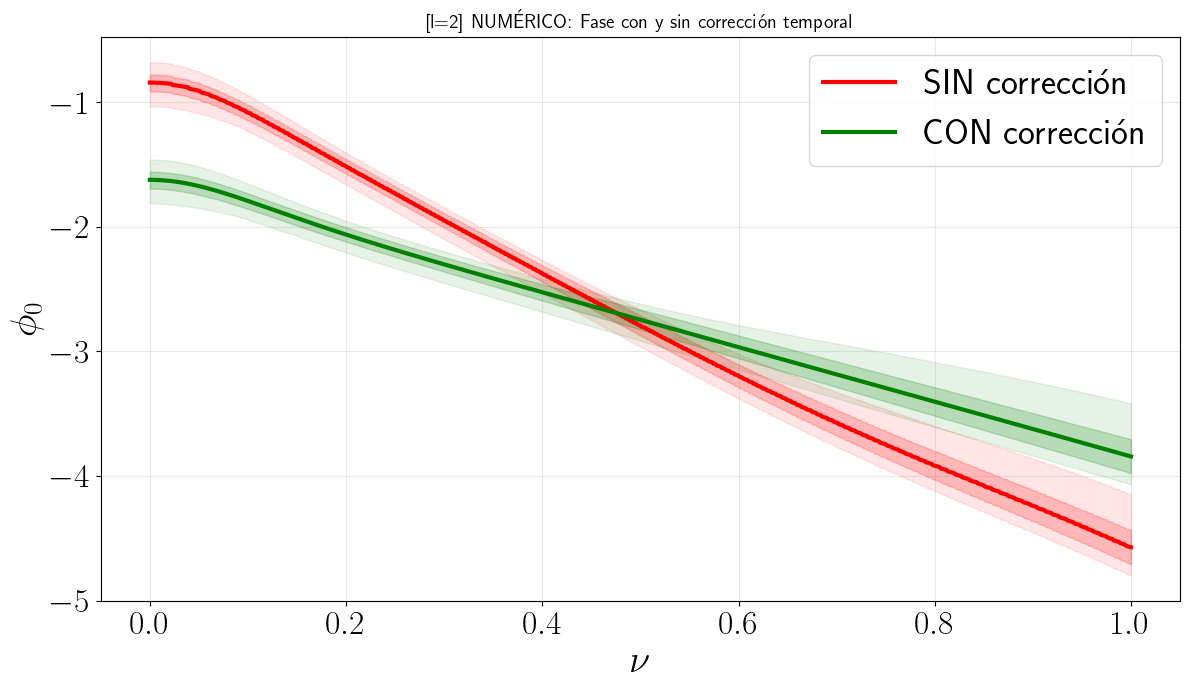

✓ Gráfica guardada: PHASE_NUMERIC_SUPERPOSED.pdf


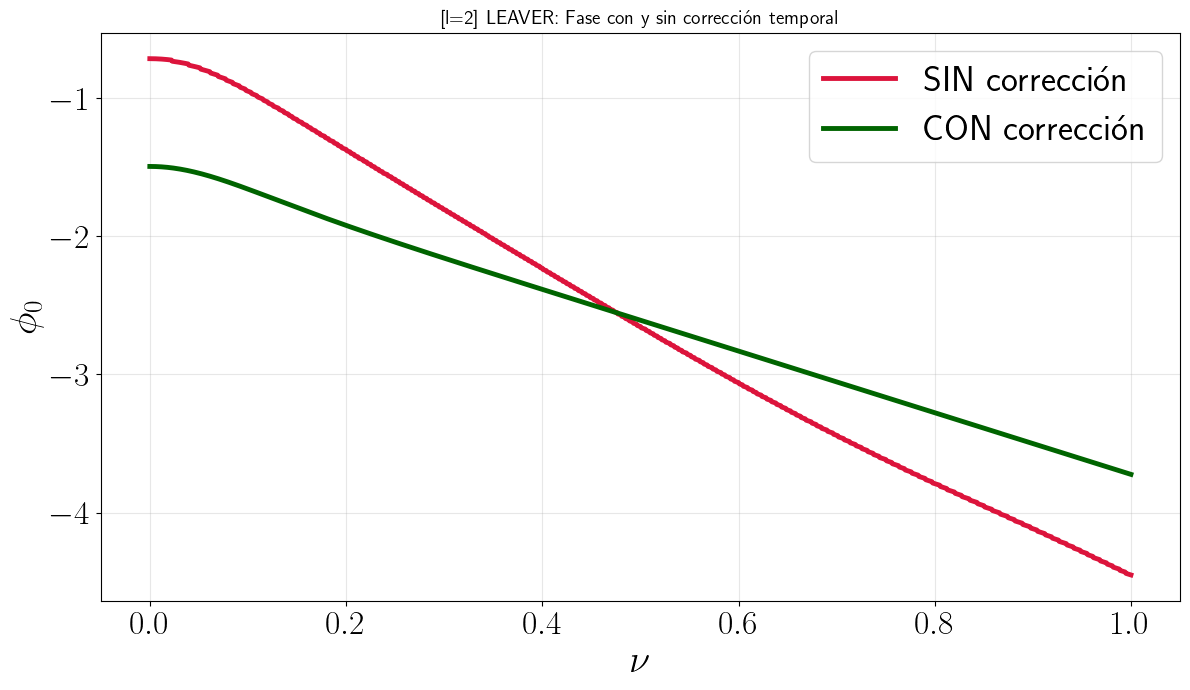

✓ Gráfica guardada: PHASE_LEAVER_SUPERPOSED.pdf


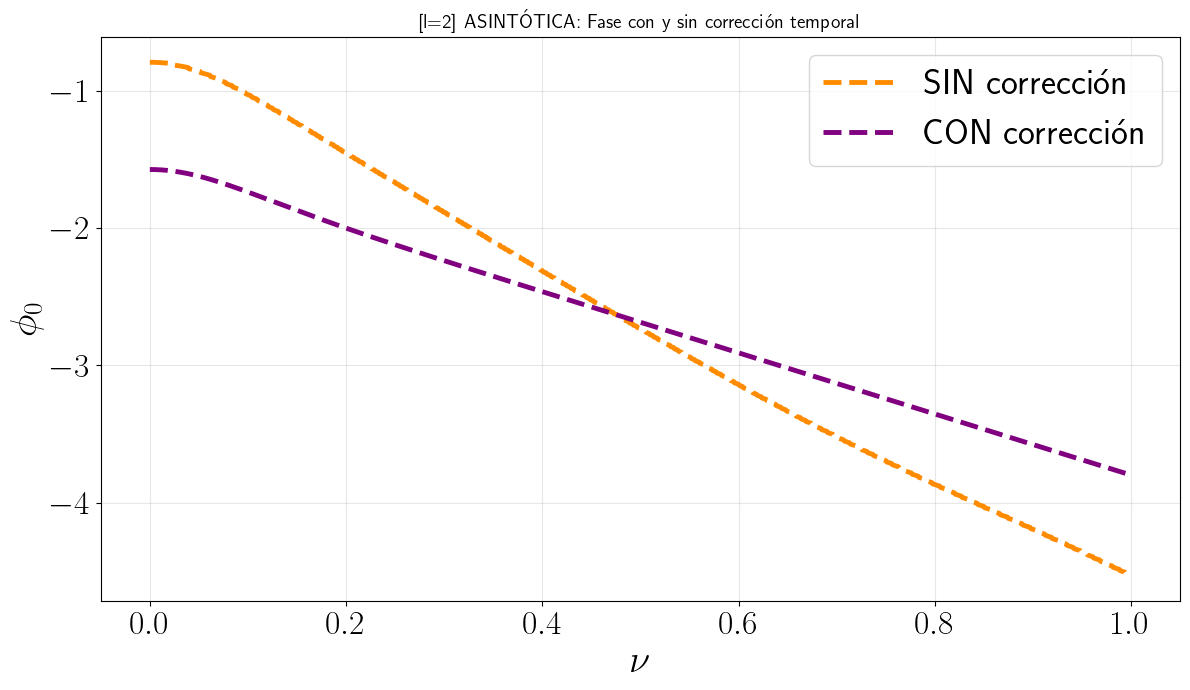

✓ Gráfica guardada: PHASE_ASYMPTOTIC_SUPERPOSED.pdf

✓ Los tres plots superpuestos se han generado correctamente


In [ ]:
# ============================================================
# SEPARATE PLOTS WITH SUPERPOSED CURVES
# Each plot shows WITHOUT correction and WITH correction
# in the same panel
# ============================================================

plt.rcParams['text.usetex'] = True

# ============================================================
# PLOT 1: NUMERICAL ONLY (superposed)
# ============================================================
fig, ax = plt.subplots(figsize=(12, 7))

# WITHOUT correction
ax.fill_between(nu_grid_l2, phase_stats_uncorr_uw['p3s_lo'], phase_stats_uncorr_uw['p3s_hi'],
                color='red', alpha=0.10, zorder=1)
ax.fill_between(nu_grid_l2, phase_stats_uncorr_uw['p1s_lo'], phase_stats_uncorr_uw['p1s_hi'],
                color='red', alpha=0.20, zorder=2)
ax.plot(nu_grid_l2, phase_stats_uncorr_uw['med'], color='red', lw=3, 
        label=r'WITHOUT correction', zorder=5)

# WITH correction
ax.fill_between(nu_grid_l2, phase_stats_l2_uw['p3s_lo'], phase_stats_l2_uw['p3s_hi'],
                color='green', alpha=0.10, zorder=1)
ax.fill_between(nu_grid_l2, phase_stats_l2_uw['p1s_lo'], phase_stats_l2_uw['p1s_hi'],
                color='green', alpha=0.20, zorder=2)
ax.plot(nu_grid_l2, phase_stats_l2_uw['med'], color='green', lw=3, 
        label=r'WITH correction', zorder=5)

ax.set_xlabel(r'$\nu$', fontsize=28)
ax.set_ylabel(r'$\phi_{0}$', fontsize=28)
ax.set_title(r'[l=2] NUMERICAL: Phase with and without temporal correction',
             fontsize=14, fontweight='bold')
ax.tick_params(axis='both', labelsize=24)
ax.grid(alpha=0.3)
ax.legend(frameon=True, fontsize=26, loc='best')

plt.tight_layout()
plt.savefig('PHASE_NUMERIC_SUPERPOSED.pdf', bbox_inches='tight')
plt.show()

print("✓ Figure saved: PHASE_NUMERIC_SUPERPOSED.pdf")


# ============================================================
# PLOT 2: LEAVER ONLY (superposed)
# ============================================================
fig, ax = plt.subplots(figsize=(12, 7))

# WITHOUT correction
ax.plot(nu_grid_l2, phi_leaver_uncorr_uw, color='crimson', lw=3.5, 
        label=r'WITHOUT correction', zorder=5)

# WITH correction
ax.plot(nu_grid_l2, phi_leaver_uw, color='darkgreen', lw=3.5, 
        label=r'WITH correction', zorder=6)

ax.set_xlabel(r'$\nu$', fontsize=28)
ax.set_ylabel(r'$\phi_{0}$', fontsize=28)
ax.set_title(r'[l=2] LEAVER: Phase with and without temporal correction',
             fontsize=14, fontweight='bold')
ax.tick_params(axis='both', labelsize=24)
ax.grid(alpha=0.3)
ax.legend(frameon=True, fontsize=26, loc='best')

plt.tight_layout()
plt.savefig('PHASE_LEAVER_SUPERPOSED.pdf', bbox_inches='tight')
plt.show()

print("✓ Figure saved: PHASE_LEAVER_SUPERPOSED.pdf")


# ============================================================
# PLOT 3: ASYMPTOTIC ONLY (superposed)
# ============================================================
fig, ax = plt.subplots(figsize=(12, 7))

# WITHOUT correction
ax.plot(nu_grid_l2, phi_asymp_uncorr_uw, color='darkorange', lw=3.5, 
        ls='--', label=r'WITHOUT correction', zorder=5)

# WITH correction
ax.plot(nu_grid_l2, phi_asymp_uw, color='purple', lw=3.5, 
        ls='--', label=r'WITH correction', zorder=6)

ax.set_xlabel(r'$\nu$', fontsize=28)
ax.set_ylabel(r'$\phi_{0}$', fontsize=28)
ax.set_title(r'[l=2] ASYMPTOTIC: Phase with and without temporal correction',
             fontsize=14, fontweight='bold')
ax.tick_params(axis='both', labelsize=24)
ax.grid(alpha=0.3)
ax.legend(frameon=True, fontsize=26, loc='best')

plt.tight_layout()
plt.savefig('PHASE_ASYMPTOTIC_SUPERPOSED.pdf', bbox_inches='tight')
plt.show()

print("✓ Figure saved: PHASE_ASYMPTOTIC_SUPERPOSED.pdf")

print("\n" + "="*70)
print("✓ The three superposed plots have been generated successfully")
print("="*70)

### continuation

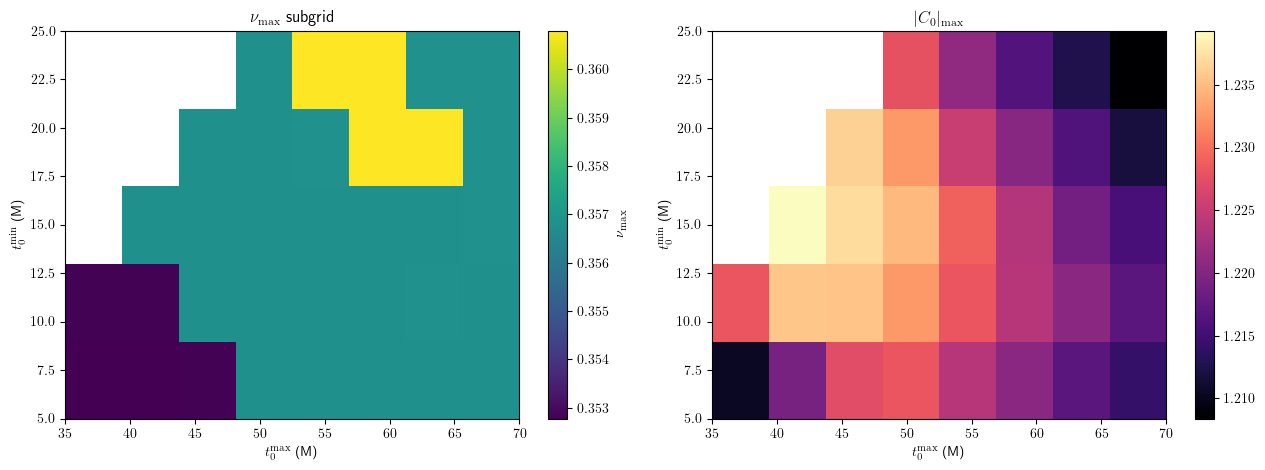

[l=2] Sensibilidad al filtro:
  nu_max: 0.35681 [0.35278, 0.36080]
  |C_0|_max: 1.223766 [1.208396, 1.239303]

[l=2] Ancho de la resonancia:
  |C_0| > (1-0.001)*peak -> nu in [0.36900, 0.38700] (ancho 0.01800)
  |C_0| > (1-0.005)*peak -> nu in [0.35800, 0.39800] (ancho 0.04000)
  |C_0| > (1-0.01)*peak -> nu in [0.34900, 0.40700] (ancho 0.05800)

[l=2] Localización del máximo:
  nu_max (numérico)  = 0.37747
  nu_max (Leaver)    = 0.37273
  nu_max (asintótica)= 0.37357
  Δnu (num - Leaver) = 0.00474 (1.27 %)

[l=2] Acuerdo en altura:
  Numérico en nu_max_num = 1.145713
  Leaver   en nu_max_num = 1.118028
  Diferencia relativa = +2.476 %


In [ ]:
# ============================================================
# CELL 7 — DIAGNOSTICS (l = 2, as a function of nu)
# ============================================================
# Robustness tests:
#   (a) Sensitivity to filtering
#   (b) Resonance width in nu
#   (c) Numerical vs Leaver comparison
# ============================================================

from scipy.optimize import minimize_scalar
from scipy.interpolate import UnivariateSpline


# ============================================================
# Helper: subgrid maximum in nu
# ============================================================
def nu_max_subgrid(nu_grid, curve, window_half=0.02):
    if np.all(np.isnan(curve)):
        return np.nan

    i_peak = np.nanargmax(curve)
    nu_peak = nu_grid[i_peak]

    mask = (nu_grid >= nu_peak - window_half) & (nu_grid <= nu_peak + window_half)
    nu_loc = nu_grid[mask]
    c_loc = curve[mask]

    if len(nu_loc) < 5 or np.any(np.isnan(c_loc)):
        return nu_peak

    spl = UnivariateSpline(nu_loc, c_loc, k=4, s=0)
    res = minimize_scalar(lambda x: -spl(x),
                          bounds=(nu_loc[0], nu_loc[-1]),
                          method='bounded')
    return float(res.x)


# ============================================================
# (a) FILTER SENSITIVITY
# ============================================================
min_t0_scan = np.arange(5, 26, 5)
max_t1_scan = np.arange(35, 71, 5)

nu_max_scan = np.full((len(min_t0_scan), len(max_t1_scan)), np.nan)
peak_val_scan = np.full_like(nu_max_scan, np.nan)
n_keep_scan = np.full_like(nu_max_scan, np.nan)

for i, mt0 in enumerate(min_t0_scan):
    for j, mt1 in enumerate(max_t1_scan):

        if mt1 <= mt0 + MIN_DURATION:
            continue

        sel = ((tmn_arr >= mt0) &
               (tmx_arr <= mt1) &
               (duration_arr >= MIN_DURATION))

        if sel.sum() < 5:
            continue

        sub = abs_C0_matrix_l2[:, sel]
        med = np.nanmedian(sub, axis=1)

        nu_max_scan[i, j] = nu_max_subgrid(nu_grid_l2, med)
        peak_val_scan[i, j] = np.nanmax(med)
        n_keep_scan[i, j] = sel.sum()


# ---------- Plot heatmaps ----------
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

# nu_max
im0 = axes[0].imshow(nu_max_scan, origin='lower', aspect='auto',
                    extent=[max_t1_scan[0], max_t1_scan[-1],
                            min_t0_scan[0], min_t0_scan[-1]],
                    cmap='viridis')
axes[0].set_xlabel(r'$t_0^{\max}$ (M)')
axes[0].set_ylabel(r'$t_0^{\min}$ (M)')
axes[0].set_title(r'$\nu_{\max}$ subgrid')
cb0 = plt.colorbar(im0, ax=axes[0])
cb0.set_label(r'$\nu_{\max}$')

# peak value
im1 = axes[1].imshow(peak_val_scan, origin='lower', aspect='auto',
                    extent=[max_t1_scan[0], max_t1_scan[-1],
                            min_t0_scan[0], min_t0_scan[-1]],
                    cmap='magma')
axes[1].set_xlabel(r'$t_0^{\max}$ (M)')
axes[1].set_ylabel(r'$t_0^{\min}$ (M)')
axes[1].set_title(r'$|C_0|_{\max}$')
plt.colorbar(im1, ax=axes[1])

plt.tight_layout()
plt.show()


# ---------- Summary ----------
print("[l=2] Filter sensitivity:")
print(f"  nu_max: {np.nanmedian(nu_max_scan):.5f} "
      f"[{np.nanmin(nu_max_scan):.5f}, {np.nanmax(nu_max_scan):.5f}]")
print(f"  |C_0|_max: {np.nanmedian(peak_val_scan):.6f} "
      f"[{np.nanmin(peak_val_scan):.6f}, {np.nanmax(peak_val_scan):.6f}]")


# ============================================================
# (b) RESONANCE WIDTH
# ============================================================
peak_value_med = np.nanmax(median_C0_l2)

print("\n[l=2] Resonance width:")

for eps in [0.001, 0.005, 0.01]:
    threshold = (1 - eps) * peak_value_med
    mask = median_C0_l2 >= threshold

    if np.any(mask):
        nu_lo = nu_grid_l2[mask].min()
        nu_hi = nu_grid_l2[mask].max()

        print(f"  |C_0| > (1-{eps})*peak -> nu in [{nu_lo:.5f}, {nu_hi:.5f}] "
              f"(width {nu_hi - nu_lo:.5f})")


# ============================================================
# (c) NUMERICAL vs LEAVER COMPARISON
# ============================================================
nu_max_num    = nu_max_subgrid(nu_grid_l2, median_C0_l2)
nu_max_leaver = nu_max_subgrid(nu_grid_l2, np.abs(C_leaver_l2[:, 0]))
nu_max_asymp  = nu_max_subgrid(nu_grid_l2, np.abs(C_asymp_l2[:, 0]))

C0_num_at_num    = np.interp(nu_max_num,    nu_grid_l2, median_C0_l2)
C0_num_at_leaver = np.interp(nu_max_leaver, nu_grid_l2, median_C0_l2)
C0_leaver_at_num = np.interp(nu_max_num,    nu_grid_l2, np.abs(C_leaver_l2[:, 0]))

print("\n[l=2] Maximum location:")
print(f"  nu_max (numerical)   = {nu_max_num:.5f}")
print(f"  nu_max (Leaver)      = {nu_max_leaver:.5f}")
print(f"  nu_max (asymptotic)  = {nu_max_asymp:.5f}")
print(f"  Δnu (num - Leaver)   = {abs(nu_max_num - nu_max_leaver):.5f} "
      f"({abs(nu_max_num - nu_max_leaver)/nu_max_leaver*100:.2f} %)")

print("\n[l=2] Amplitude agreement:")
print(f"  Numerical at nu_max_num = {C0_num_at_num:.6f}")
print(f"  Leaver   at nu_max_num  = {C0_leaver_at_num:.6f}")
print(f"  Relative difference = "
      f"{(C0_num_at_num - C0_leaver_at_num)/C0_leaver_at_num*100:+.3f} %")

nu_max numérico = 0.37747
nu_max Leaver   = 0.37273
nu_max asintótico = 0.37357


/var/folders/4w/llt2155x2g31xxdrldln6zxh0000gp/T/ipykernel_28270/238352802.py:162: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


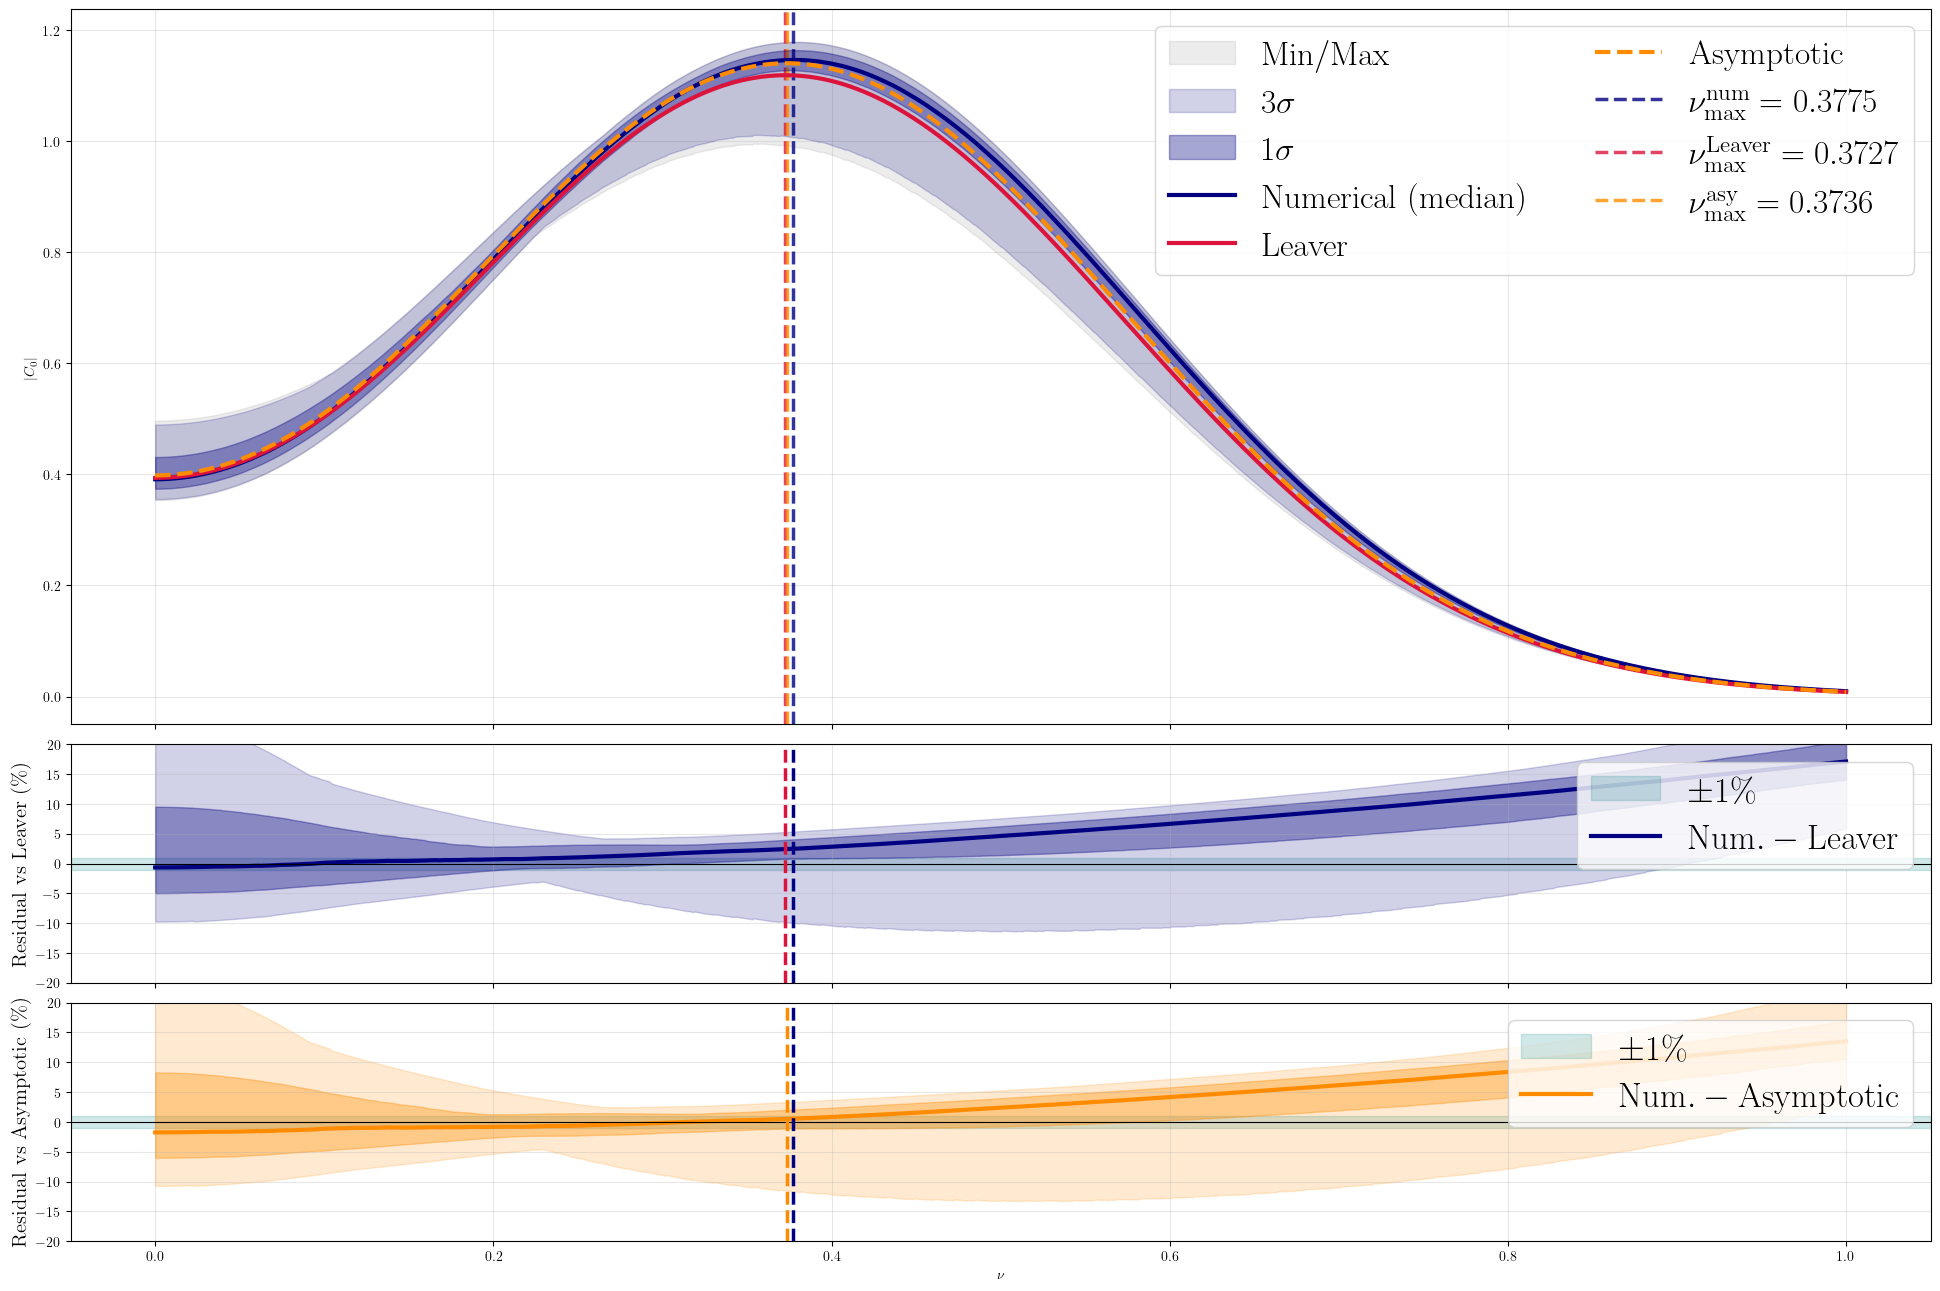

In [ ]:
# ============================================================
# CELL 8 — FINAL PLOT (l = 2, as a function of nu)
# ============================================================

plt.rcParams['text.usetex'] = True

fig, (ax, axr, axra) = plt.subplots(
    3, 1, figsize=(24, 16), sharex=True,
    gridspec_kw={'height_ratios': [3, 1, 1], 'hspace': 0.05}
)

# --- Colors ---
COLOR_NUM    = 'navy'
COLOR_LEAVER = 'crimson'
COLOR_ASYMP  = 'darkorange'
COLOR_REF    = 'teal'
COLOR_ZERO   = 'black'

# ============================================================
# NUMERICAL DATA (already filtered)
# ============================================================

median_C0 = median_C0_l2
p1s_lo = p1s_lo_l2
p1s_hi = p1s_hi_l2
p3s_lo = p3s_lo_l2
p3s_hi = p3s_hi_l2
env_min = env_min_l2
env_max = env_max_l2

# --- Theory ---
leaver_curve = np.abs(C_leaver_l2[:, 0])
asymp_curve  = np.abs(C_asymp_l2[:, 0])

# --- Maxima ---
nu_max_num    = nu_max_subgrid(nu_grid_l2, median_C0)
nu_max_leaver = nu_max_subgrid(nu_grid_l2, leaver_curve)
nu_max_asymp  = nu_max_subgrid(nu_grid_l2, asymp_curve)

print(f"Numerical nu_max = {nu_max_num:.5f}")
print(f"Leaver nu_max    = {nu_max_leaver:.5f}")
print(f"Asymptotic nu_max = {nu_max_asymp:.5f}")

# ============================================================
# MAIN PANEL
# ============================================================

ax.fill_between(nu_grid_l2, env_min, env_max,
                color='gray', alpha=0.15, zorder=1,
                label=r'$\mathrm{Min/Max}$')

ax.fill_between(nu_grid_l2, p3s_lo, p3s_hi,
                color=COLOR_NUM, alpha=0.18, zorder=2,
                label=r'$3\sigma$')

ax.fill_between(nu_grid_l2, p1s_lo, p1s_hi,
                color=COLOR_NUM, alpha=0.35, zorder=3,
                label=r'$1\sigma$')

ax.plot(nu_grid_l2, median_C0,
        color=COLOR_NUM, lw=3, zorder=4,
        label=r'$\mathrm{Numerical\ (median)}$')

ax.plot(nu_grid_l2, leaver_curve,
        color=COLOR_LEAVER, lw=3, zorder=5,
        label=r'$\mathrm{Leaver}$')

ax.plot(nu_grid_l2, asymp_curve,
        color=COLOR_ASYMP, lw=3, ls='--', zorder=5,
        label=r'$\mathrm{Asymptotic}$')

# --- Vertical lines ---
ax.axvline(nu_max_num,
           color=COLOR_NUM, lw=2.5, ls='--', alpha=0.8,
           label=fr'$\nu_{{\max}}^{{\mathrm{{num}}}} = {nu_max_num:.4f}$')

ax.axvline(nu_max_leaver,
           color=COLOR_LEAVER, lw=2.5, ls='--', alpha=0.8,
           label=fr'$\nu_{{\max}}^{{\mathrm{{Leaver}}}} = {nu_max_leaver:.4f}$')

ax.axvline(nu_max_asymp,
           color=COLOR_ASYMP, lw=2.5, ls='--', alpha=0.8,
           label=fr'$\nu_{{\max}}^{{\mathrm{{asy}}}} = {nu_max_asymp:.4f}$')

ax.set_ylabel(r'$|C_0|$')
ax.grid(alpha=0.3)
ax.legend(frameon=True, loc='upper right', ncol=2, fontsize=24)

# ============================================================
# RESIDUALS VS LEAVER
# ============================================================

safe_L = leaver_curve > 0

res_med_L    = np.full_like(nu_grid_l2, np.nan)
res_p3s_lo_L = np.full_like(nu_grid_l2, np.nan)
res_p1s_lo_L = np.full_like(nu_grid_l2, np.nan)
res_p1s_hi_L = np.full_like(nu_grid_l2, np.nan)
res_p3s_hi_L = np.full_like(nu_grid_l2, np.nan)

res_med_L[safe_L]    = (median_C0[safe_L] - leaver_curve[safe_L]) / leaver_curve[safe_L] * 100
res_p3s_lo_L[safe_L] = (p3s_lo[safe_L]    - leaver_curve[safe_L]) / leaver_curve[safe_L] * 100
res_p1s_lo_L[safe_L] = (p1s_lo[safe_L]    - leaver_curve[safe_L]) / leaver_curve[safe_L] * 100
res_p1s_hi_L[safe_L] = (p1s_hi[safe_L]    - leaver_curve[safe_L]) / leaver_curve[safe_L] * 100
res_p3s_hi_L[safe_L] = (p3s_hi[safe_L]    - leaver_curve[safe_L]) / leaver_curve[safe_L] * 100

axr.axhspan(-1, 1, color=COLOR_REF, alpha=0.18, label=r'$\pm 1\%$')

axr.fill_between(nu_grid_l2, res_p3s_lo_L, res_p3s_hi_L, color=COLOR_NUM, alpha=0.18)
axr.fill_between(nu_grid_l2, res_p1s_lo_L, res_p1s_hi_L, color=COLOR_NUM, alpha=0.35)

axr.plot(nu_grid_l2, res_med_L, color=COLOR_NUM, lw=3,
         label=r'$\mathrm{Num.} - \mathrm{Leaver}$')

axr.axhline(0, color=COLOR_ZERO, lw=0.8)
axr.axvline(nu_max_num, color=COLOR_NUM, lw=2.5, ls='--')
axr.axvline(nu_max_leaver, color=COLOR_LEAVER, lw=2.5, ls='--')

axr.set_ylim(-20, 20)
axr.set_ylabel(r'$\mathrm{Residual\ vs\ Leaver\ (\%)}$', fontsize='15')
axr.grid(alpha=0.3)
axr.legend(frameon=True, loc='upper right', fontsize='25')

# ============================================================
# RESIDUALS VS ASYMPTOTIC
# ============================================================

safe_A = asymp_curve > 0

res_med_A    = np.full_like(nu_grid_l2, np.nan)
res_p3s_lo_A = np.full_like(nu_grid_l2, np.nan)
res_p1s_lo_A = np.full_like(nu_grid_l2, np.nan)
res_p1s_hi_A = np.full_like(nu_grid_l2, np.nan)
res_p3s_hi_A = np.full_like(nu_grid_l2, np.nan)

res_med_A[safe_A]    = (median_C0[safe_A] - asymp_curve[safe_A]) / asymp_curve[safe_A] * 100
res_p3s_lo_A[safe_A] = (p3s_lo[safe_A]    - asymp_curve[safe_A]) / asymp_curve[safe_A] * 100
res_p1s_lo_A[safe_A] = (p1s_lo[safe_A]    - asymp_curve[safe_A]) / asymp_curve[safe_A] * 100
res_p1s_hi_A[safe_A] = (p1s_hi[safe_A]    - asymp_curve[safe_A]) / asymp_curve[safe_A] * 100
res_p3s_hi_A[safe_A] = (p3s_hi[safe_A]    - asymp_curve[safe_A]) / asymp_curve[safe_A] * 100

axra.axhspan(-1, 1, color=COLOR_REF, alpha=0.18, label=r'$\pm 1\%$')

axra.fill_between(nu_grid_l2, res_p3s_lo_A, res_p3s_hi_A,
                  color=COLOR_ASYMP, alpha=0.18)
axra.fill_between(nu_grid_l2, res_p1s_lo_A, res_p1s_hi_A,
                  color=COLOR_ASYMP, alpha=0.35)

axra.plot(nu_grid_l2, res_med_A, color=COLOR_ASYMP, lw=3,
          label=r'$\mathrm{Num.} - \mathrm{Asymptotic}$')

axra.axhline(0, color=COLOR_ZERO, lw=0.8)
axra.axvline(nu_max_num, color=COLOR_NUM, lw=2.5, ls='--')
axra.axvline(nu_max_asymp, color=COLOR_ASYMP, lw=2.5, ls='--')

axra.set_ylim(-20, 20)
axra.set_xlabel(r'$\nu$')
axra.set_ylabel(r'$\mathrm{Residual\ vs\ Asymptotic\ (\%)}$', fontsize='15')
axra.grid(alpha=0.3)
axra.legend(frameon=True, loc='upper right', fontsize='25')

# ============================================================
# SAVE
# ============================================================

plt.tight_layout()
#plt.savefig('fig6_right_l2_nu.pdf', bbox_inches='tight')
plt.show()

nu_max numérico = 0.37747
nu_max Leaver   = 0.37273
nu_max asintótico = 0.37357


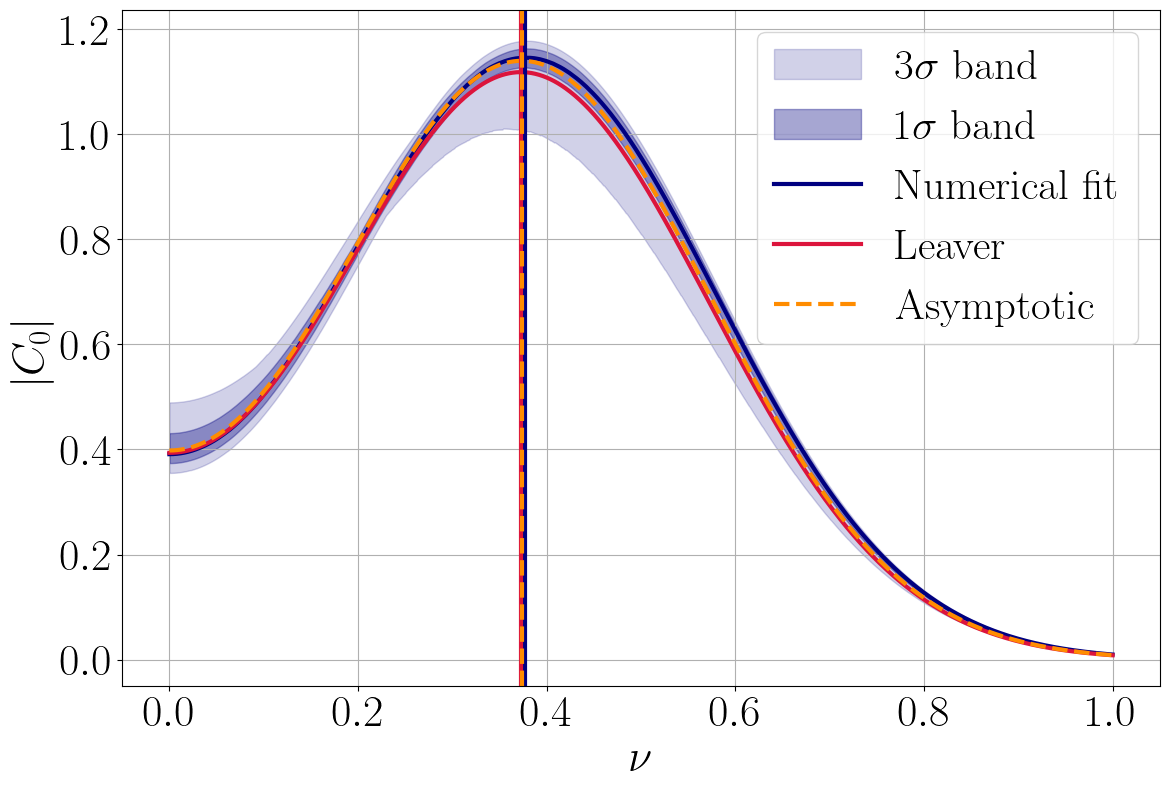

In [ ]:
# ============================================================
# FIGURE 1 — MAIN CURVES (l=2, as a function of nu)
# ============================================================
plt.rcParams['text.usetex'] = True

print(f"Numerical nu_max = {nu_max_num:.5f}")
print(f"Leaver nu_max    = {nu_max_leaver:.5f}")
print(f"Asymptotic nu_max = {nu_max_asymp:.5f}")

fig, ax = plt.subplots(figsize=(12, 8))

COLOR_NUM    = 'navy'
COLOR_LEAVER = 'crimson'
COLOR_ASYMP  = 'darkorange'

# ============================================================
# HANDLES
# ============================================================
#h_env = ax.fill_between(nu_grid_l2, env_min, env_max,
#                        color='gray', alpha=0.15)
h_3s  = ax.fill_between(nu_grid_l2, p3s_lo, p3s_hi,
                        color=COLOR_NUM, alpha=0.18)
h_1s  = ax.fill_between(nu_grid_l2, p1s_lo, p1s_hi,
                        color=COLOR_NUM, alpha=0.35)

h_num, = ax.plot(nu_grid_l2, median_C0,
                 color=COLOR_NUM, lw=3)
h_leaver, = ax.plot(nu_grid_l2, leaver_curve,
                    color=COLOR_LEAVER, lw=3)
h_asymp, = ax.plot(nu_grid_l2, asymp_curve,
                   color=COLOR_ASYMP, lw=3, ls='--')

# Vertical lines (without legend)
ax.axvline(nu_max_num,    color=COLOR_NUM,    ls='-', lw=3)
ax.axvline(nu_max_leaver, color=COLOR_LEAVER, ls='-', lw=3)
ax.axvline(nu_max_asymp,  color=COLOR_ASYMP,  ls='--', lw=3)

# ============================================================
# UNIFIED LEGEND
# ============================================================
handles = [h_3s, h_1s, h_num, h_leaver, h_asymp]
labels = [
    r'$3\sigma$ $\mathrm{band}$',
    r'$1\sigma$ $\mathrm{band}$',
    r'$\mathrm{Numerical}$ $\mathrm{fit}$',
    r'$\mathrm{Leaver}$',
    r'$\mathrm{Asymptotic}$'
]

ax.legend(handles, labels,
          loc='upper right',
          fontsize=31,
          frameon=True)

# ============================================================
# STYLE
# ============================================================
ax.set_xlabel(r'$\nu$', fontsize=32)
ax.set_ylabel(r'$|C_0|$', fontsize=32)
ax.tick_params(labelsize=32)
ax.grid(True)

plt.tight_layout()
plt.savefig('QNEC l=2 n=0 NU.pdf', bbox_inches='tight', dpi=1200)
plt.show()